In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/taco-sales-dataset-20242025/taco_sales_(2024-2025).csv


In [2]:
import pandas as pd

# Replace with your actual file path
df = pd.read_csv('/kaggle/input/taco-sales-dataset-20242025/taco_sales_(2024-2025).csv')

# Display the first few rows
print(df.head())

   Order ID   Restaurant Name     Location        Order Time  \
0    770487      El Taco Loco     New York  01-08-2024 14:55   
1    671858      El Taco Loco  San Antonio  23-11-2024 17:11   
2    688508        Taco Haven       Austin  21-11-2024 20:24   
3    944962  Spicy Taco House       Dallas  21-09-2024 06:43   
4    476417     Casa del Taco  San Antonio  24-07-2024 11:01   

      Delivery Time  Delivery Duration (min) Taco Size     Taco Type  \
0  01-08-2024 15:36                       41   Regular  Chicken Taco   
1  23-11-2024 17:25                       14   Regular     Beef Taco   
2  21-11-2024 21:02                       38     Large     Pork Taco   
3  21-09-2024 07:28                       45   Regular  Chicken Taco   
4  24-07-2024 11:16                       15     Large     Pork Taco   

   Toppings Count  Distance (km)  Price ($)  Tip ($)  Weekend Order  
0               5           3.01       9.25     2.22          False  
1               1           6.20       4.2

In [3]:
df

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order
0,770487,El Taco Loco,New York,01-08-2024 14:55,01-08-2024 15:36,41,Regular,Chicken Taco,5,3.01,9.25,2.22,False
1,671858,El Taco Loco,San Antonio,23-11-2024 17:11,23-11-2024 17:25,14,Regular,Beef Taco,1,6.20,4.25,3.01,True
2,688508,Taco Haven,Austin,21-11-2024 20:24,21-11-2024 21:02,38,Large,Pork Taco,2,20.33,7.00,0.02,False
3,944962,Spicy Taco House,Dallas,21-09-2024 06:43,21-09-2024 07:28,45,Regular,Chicken Taco,2,3.00,5.50,1.90,True
4,476417,Casa del Taco,San Antonio,24-07-2024 11:01,24-07-2024 11:16,15,Large,Pork Taco,0,24.34,4.50,1.14,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,164891,La Vida Taco,Austin,27-05-2024 11:12,27-05-2024 12:11,59,Large,Veggie Taco,2,20.04,7.00,2.80,False
996,232442,The Taco Stand,San Antonio,03-04-2025 20:51,03-04-2025 21:29,38,Regular,Fish Taco,0,13.69,3.00,1.38,False
997,251729,Urban Tacos,Houston,23-01-2025 05:33,23-01-2025 06:41,68,Regular,Pork Taco,2,4.07,5.50,2.00,False
998,940215,Taco Fiesta,San Antonio,05-09-2024 15:49,05-09-2024 16:38,49,Regular,Veggie Taco,5,14.56,9.25,1.89,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order ID                 1000 non-null   int64  
 1   Restaurant Name          1000 non-null   object 
 2   Location                 1000 non-null   object 
 3   Order Time               1000 non-null   object 
 4   Delivery Time            1000 non-null   object 
 5   Delivery Duration (min)  1000 non-null   int64  
 6   Taco Size                1000 non-null   object 
 7   Taco Type                1000 non-null   object 
 8   Toppings Count           1000 non-null   int64  
 9   Distance (km)            1000 non-null   float64
 10  Price ($)                1000 non-null   float64
 11  Tip ($)                  1000 non-null   float64
 12  Weekend Order            1000 non-null   bool   
dtypes: bool(1), float64(3), int64(3), object(6)
memory usage: 94.9+ KB


In [5]:
#Restaurant Name  , Location , Taco Size , Taco Type
df['Restaurant Name'] = df['Restaurant Name'].astype(object)
df['Location'] = df['Location'].astype(object)
df['Taco Size'] = df['Taco Size'].astype(object)
df['Taco Type'] = df['Taco Type'].astype(object)

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Restaurant Name_code'] = le.fit_transform(df['Restaurant Name'])
df['Taco Type'] = le.fit_transform(df['Taco Type'])
df['Taco Size'] = le.fit_transform(df['Taco Size'])
df['Location_code'] = le.fit_transform(df['Location'])

In [7]:
print(df['Weekend Order'].value_counts(dropna=False))

Weekend Order
False    725
True     275
Name: count, dtype: int64


In [8]:
df['Weekend Order'] = df['Weekend Order'].astype(str).str.strip().str.title()
df['Weekend Order'] = df['Weekend Order'].map({'False': '0', 'True': '1'})

In [9]:
df['Order Time'] = pd.to_datetime(df['Order Time'], dayfirst=True)
df['Delivery Time'] = pd.to_datetime(df['Delivery Time'], dayfirst=True)

df['Delivery Duration'] = df['Delivery Time'] - df['Order Time']

In [10]:
df['Restaurant Name by Location'] = df['Restaurant Name'] + ' - ' + df['Location']

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Restaurant Name by Location_code'] = le.fit_transform(df['Restaurant Name by Location'])

In [12]:
df

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order,Restaurant Name_code,Location_code,Delivery Duration,Restaurant Name by Location,Restaurant Name by Location_code
0,770487,El Taco Loco,New York,2024-08-01 14:55:00,2024-08-01 15:36:00,41,1,1,5,3.01,9.25,2.22,0,1,5,0 days 00:41:00,El Taco Loco - New York,15
1,671858,El Taco Loco,San Antonio,2024-11-23 17:11:00,2024-11-23 17:25:00,14,1,0,1,6.20,4.25,3.01,1,1,7,0 days 00:14:00,El Taco Loco - San Antonio,17
2,688508,Taco Haven,Austin,2024-11-21 20:24:00,2024-11-21 21:02:00,38,0,3,2,20.33,7.00,0.02,0,6,0,0 days 00:38:00,Taco Haven - Austin,60
3,944962,Spicy Taco House,Dallas,2024-09-21 06:43:00,2024-09-21 07:28:00,45,1,1,2,3.00,5.50,1.90,1,4,2,0 days 00:45:00,Spicy Taco House - Dallas,42
4,476417,Casa del Taco,San Antonio,2024-07-24 11:01:00,2024-07-24 11:16:00,15,0,3,0,24.34,4.50,1.14,0,0,7,0 days 00:15:00,Casa del Taco - San Antonio,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,164891,La Vida Taco,Austin,2024-05-27 11:12:00,2024-05-27 12:11:00,59,0,4,2,20.04,7.00,2.80,0,3,0,0 days 00:59:00,La Vida Taco - Austin,30
996,232442,The Taco Stand,San Antonio,2025-04-03 20:51:00,2025-04-03 21:29:00,38,1,2,0,13.69,3.00,1.38,0,8,7,0 days 00:38:00,The Taco Stand - San Antonio,87
997,251729,Urban Tacos,Houston,2025-01-23 05:33:00,2025-01-23 06:41:00,68,1,3,2,4.07,5.50,2.00,0,9,3,0 days 01:08:00,Urban Tacos - Houston,93
998,940215,Taco Fiesta,San Antonio,2024-09-05 15:49:00,2024-09-05 16:38:00,49,1,4,5,14.56,9.25,1.89,0,5,7,0 days 00:49:00,Taco Fiesta - San Antonio,57


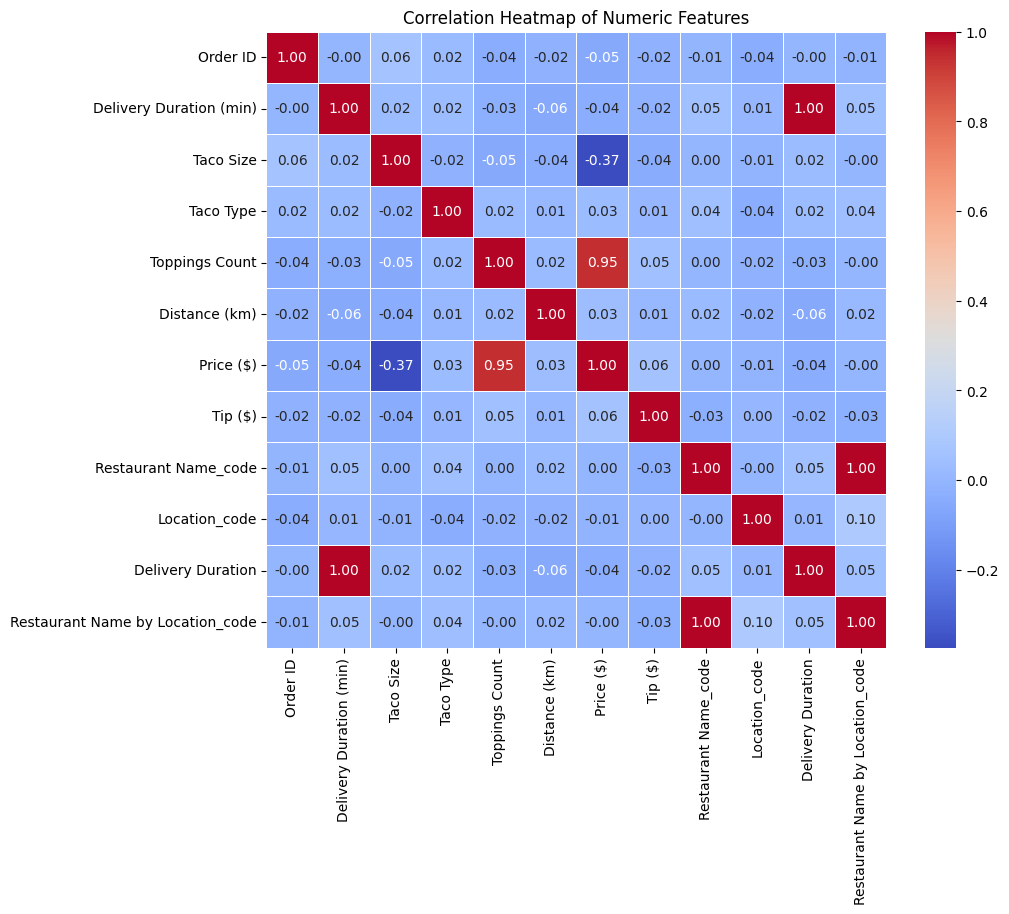

In [13]:
import seaborn as sns

#target --> Price
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

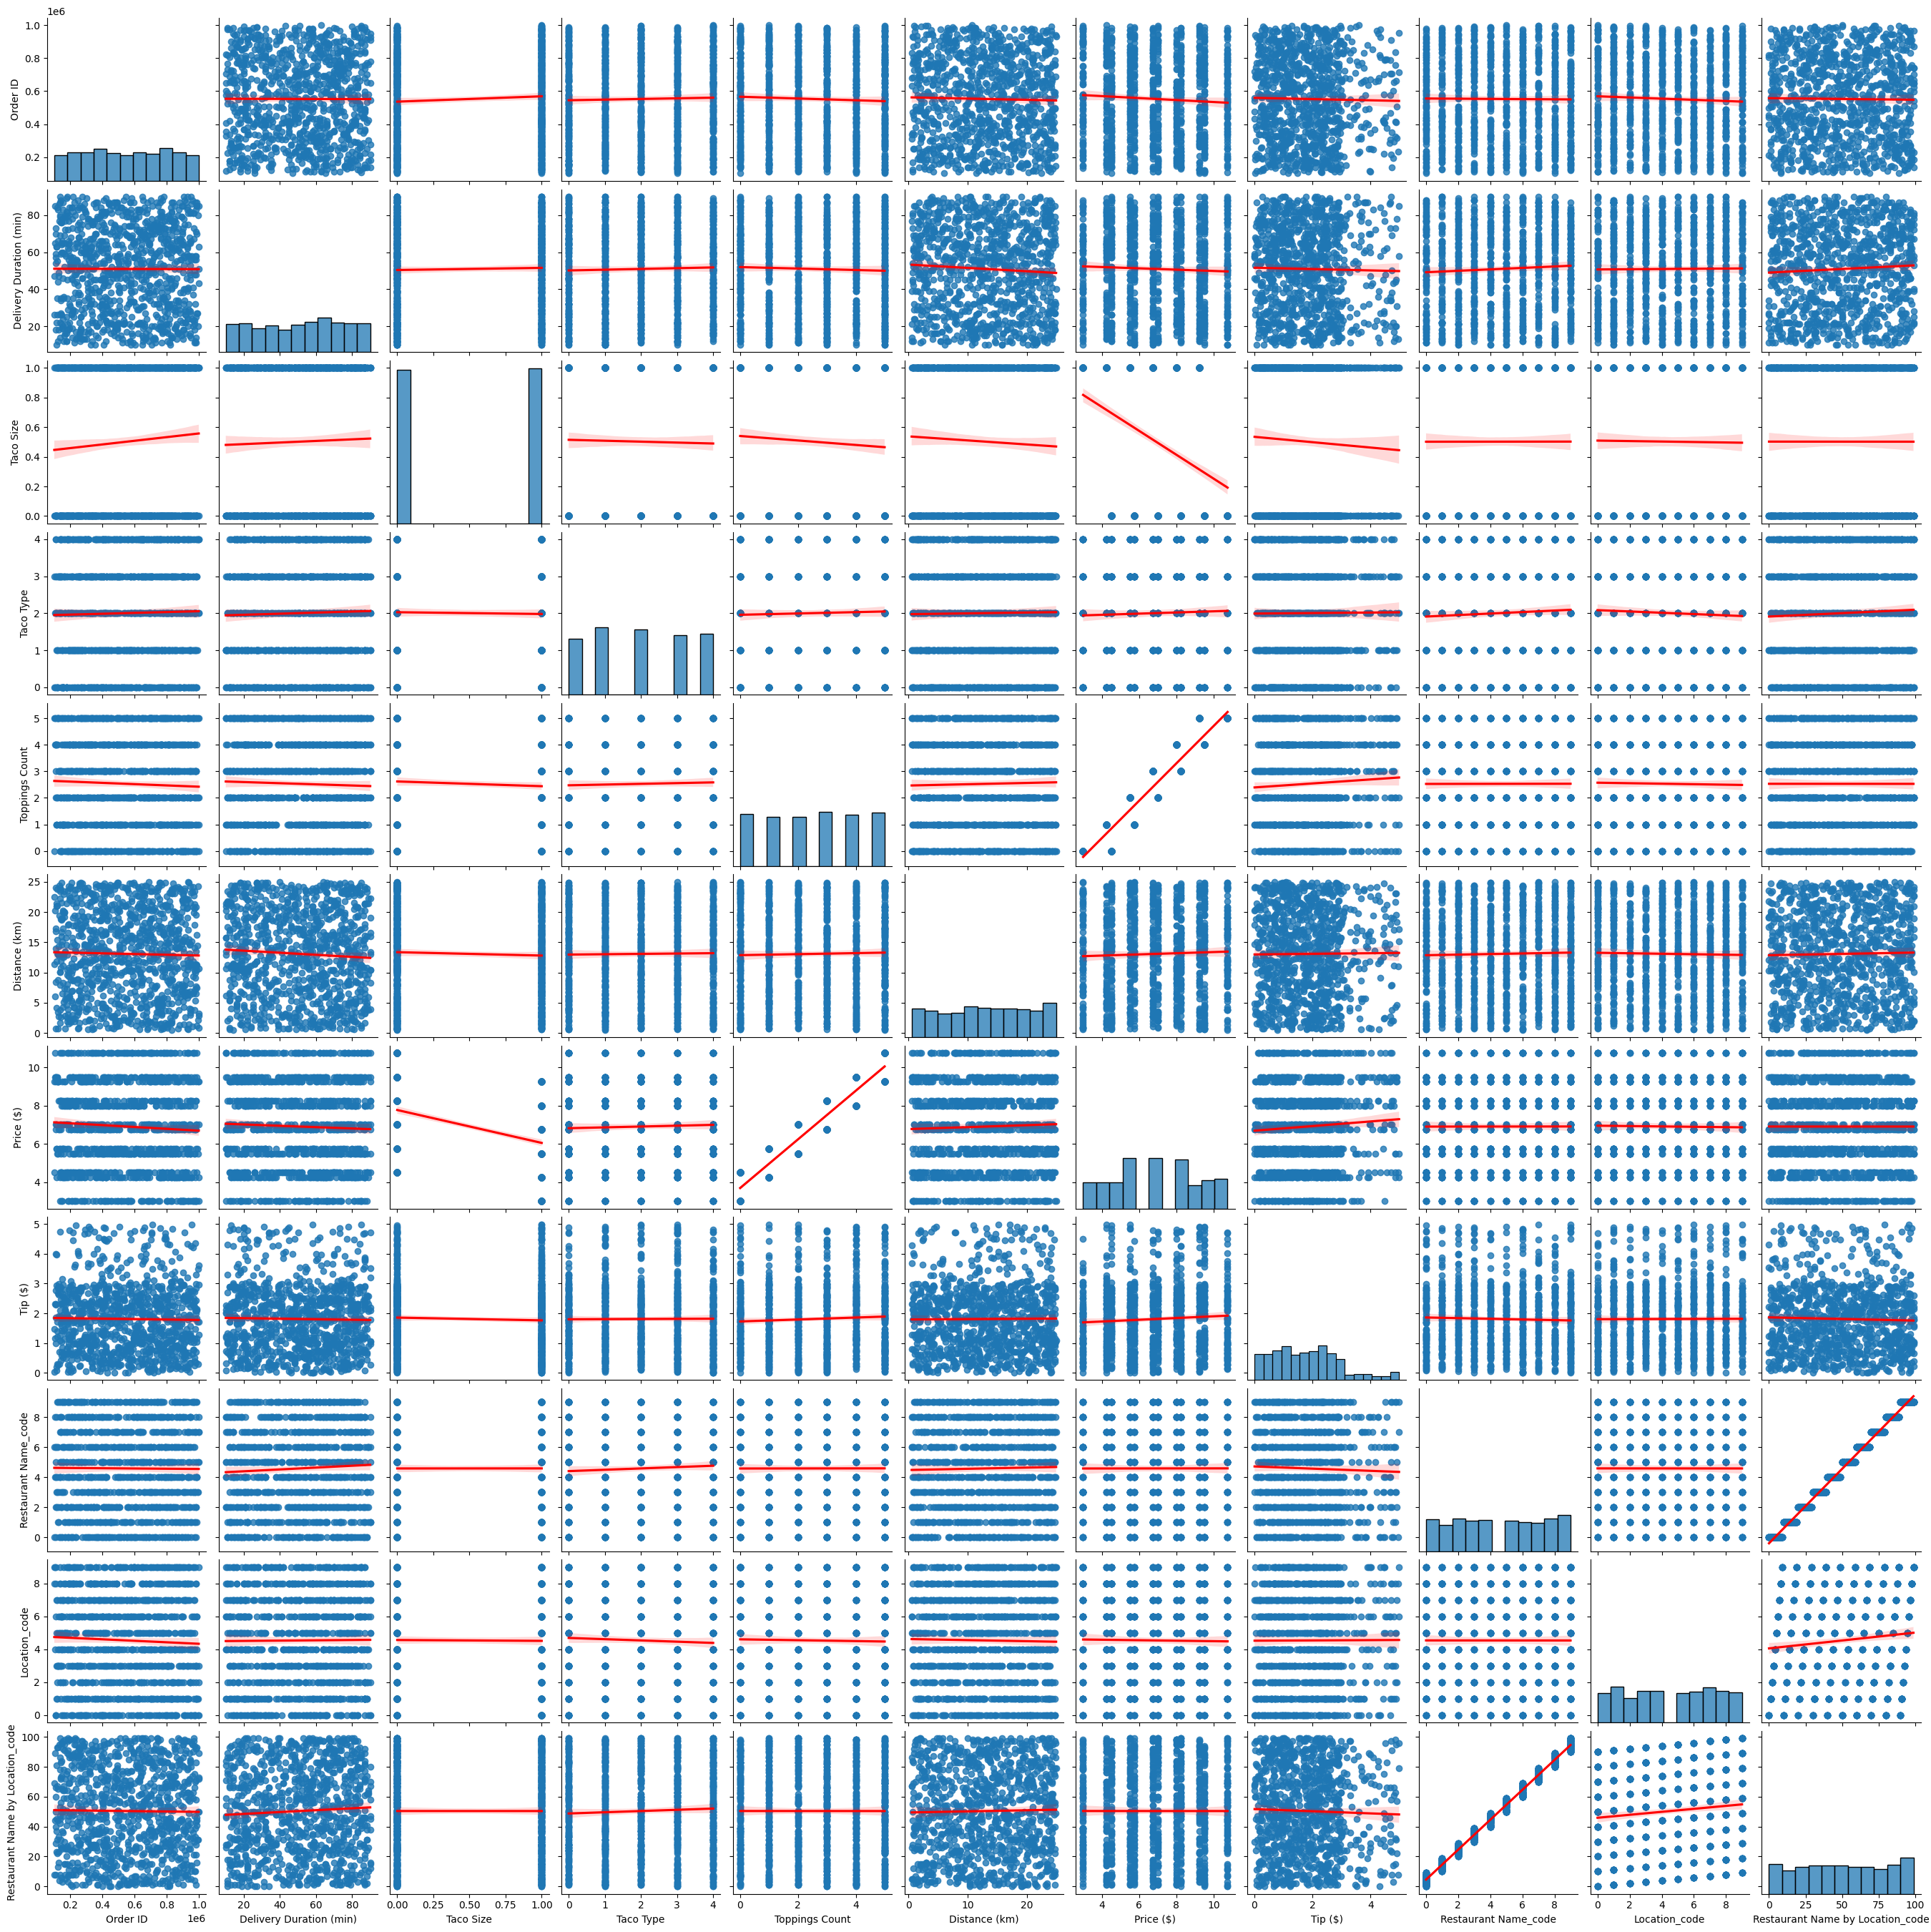

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.show()

In [15]:
# Restaurant Name by Location , price 
# Restaurant Name by Location , price  , Delivery Duration (min)

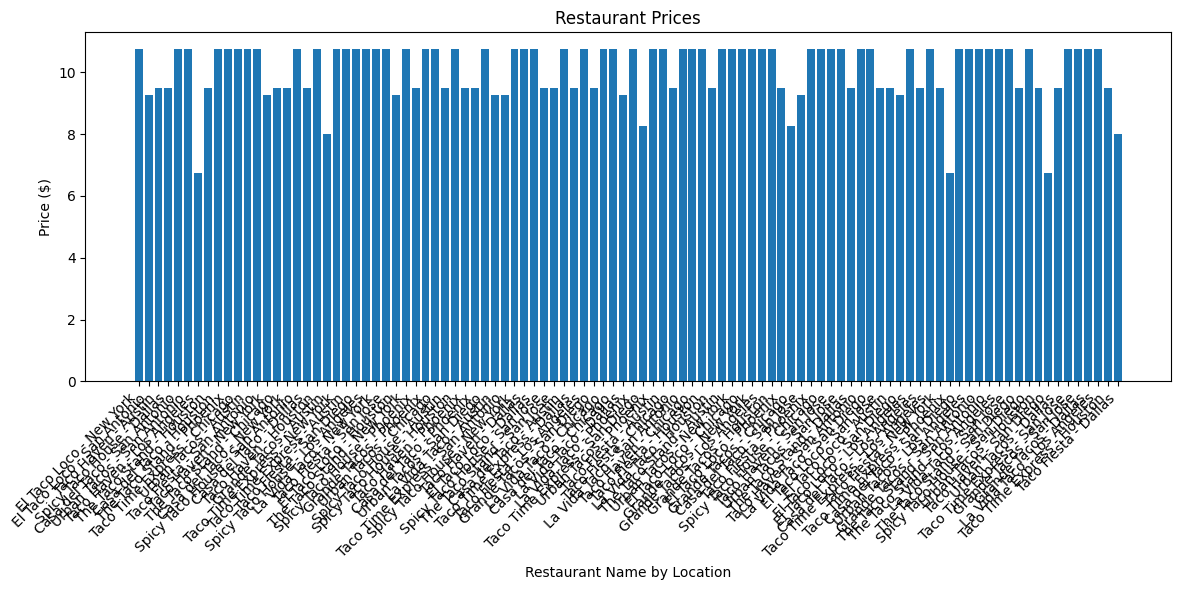

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
plt.bar(df['Restaurant Name by Location'], df['Price ($)'])
plt.xlabel('Restaurant Name by Location')
plt.ylabel('Price ($)')
plt.title('Restaurant Prices')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
df_sorted = df.sort_values(by=['Location', 'Restaurant Name'])

plt.figure(figsize=(10, 12))

<Figure size 1000x1200 with 0 Axes>

<Figure size 1000x1200 with 0 Axes>

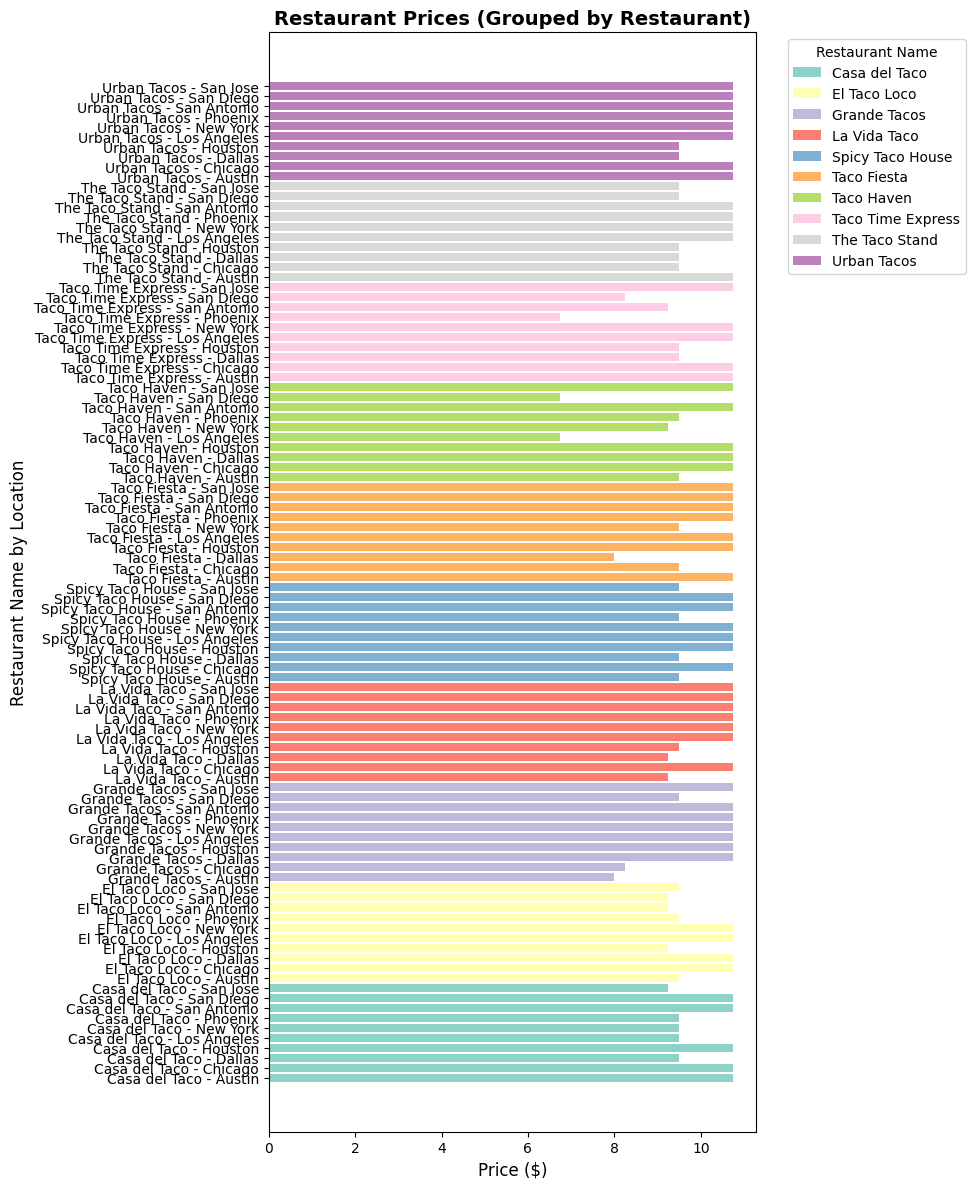

In [18]:
df_sorted = df.sort_values(by=['Restaurant Name', 'Location'])

plt.figure(figsize=(10, 12))

restaurant_colors = {
    restaurant: color
    for restaurant, color in zip(df_sorted['Restaurant Name'].unique(),
                                 plt.cm.Set3(range(len(df_sorted['Restaurant Name'].unique()))))
}

colors = [restaurant_colors[name] for name in df_sorted['Restaurant Name']]

plt.barh(df_sorted['Restaurant Name by Location'], df_sorted['Price ($)'], color=colors)

plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Restaurant Name by Location', fontsize=12)
plt.title('Restaurant Prices (Grouped by Restaurant)', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=restaurant)
                   for restaurant, color in restaurant_colors.items()]
plt.legend(handles=legend_elements, title='Restaurant Name', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

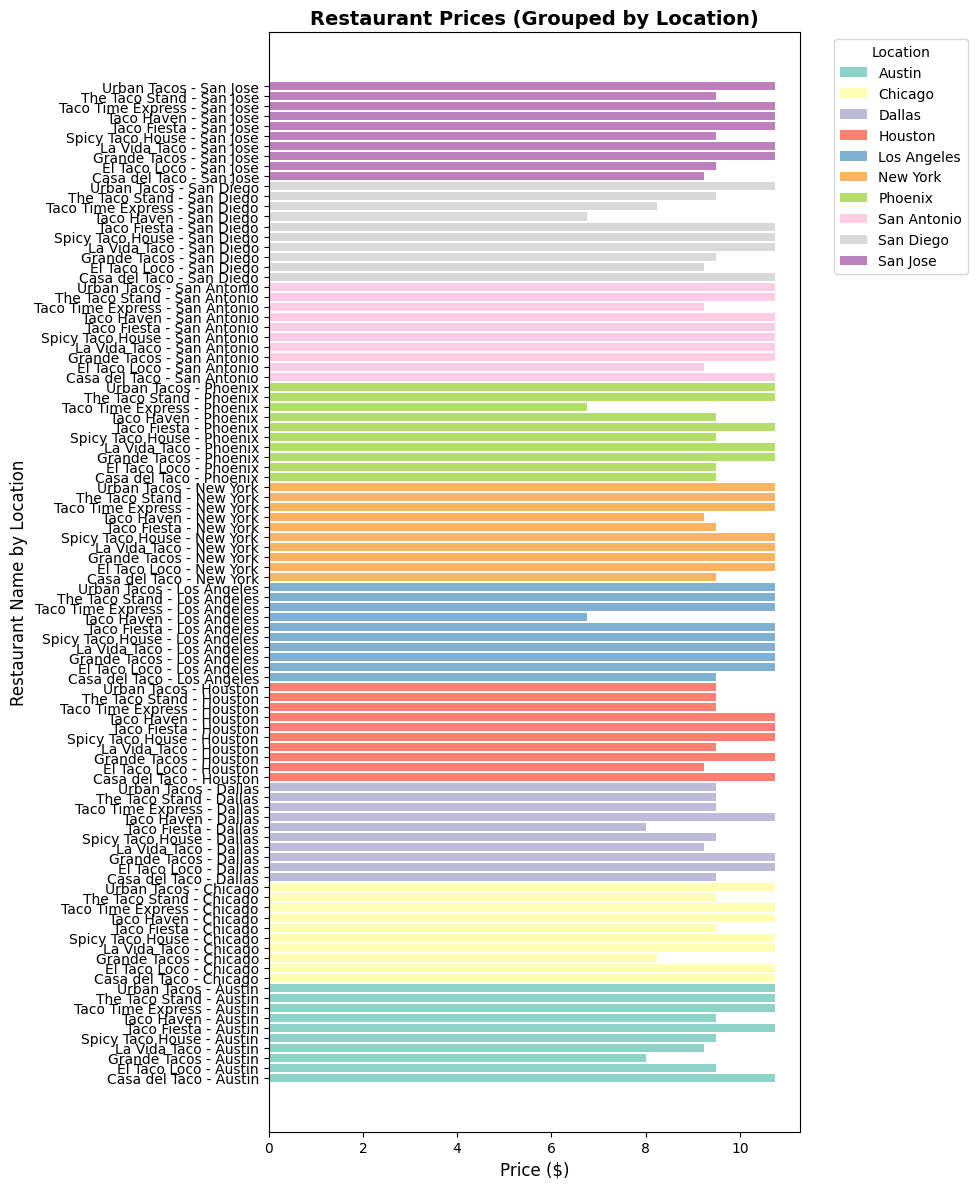

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df_sorted = df.sort_values(by=["Location", "Restaurant Name"])

plt.figure(figsize=(10, 12))

locations = df_sorted["Location"].unique()
location_colors = {
    location: color
    for location, color in zip(locations, plt.cm.Set3(range(len(locations))))
}

colors = [location_colors[loc] for loc in df_sorted["Location"]]

plt.barh(
    df_sorted["Restaurant Name by Location"],
    df_sorted["Price ($)"],
    color=colors
)

plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Restaurant Name by Location", fontsize=12)
plt.title("Restaurant Prices (Grouped by Location)", fontsize=14, fontweight="bold")

legend_elements = [
    Patch(facecolor=color, label=location)
    for location, color in location_colors.items()]

plt.legend(
    handles=legend_elements,
    title="Location",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [20]:
# df_selected -> price , tacosize , toppings count , Restaurant Name by Location

In [21]:
# Location , Restaurant Name , Delivery Duration (min)

df.groupby(['Restaurant Name', 'Location'])['Delivery Duration (min)'].mean().reset_index()

,Restaurant Name,Location,Delivery Duration (min)
0,Casa del Taco,Austin,24.285714
1,Casa del Taco,Chicago,50.333333
2,Casa del Taco,Dallas,62.909091
3,Casa del Taco,Houston,56.700000
4,Casa del Taco,Los Angeles,52.333333
...,...,...,...
95,Urban Tacos,New York,43.727273
96,Urban Tacos,Phoenix,50.000000
97,Urban Tacos,San Antonio,61.950000
98,Urban Tacos,San Diego,53.181818


In [22]:
# Weekend Order , Restaurant Name , Delivery Duration (min) , Location
df.groupby(['Restaurant Name by Location', 'Weekend Order'])['Delivery Duration (min)'].mean().reset_index()

,Restaurant Name by Location,Weekend Order,Delivery Duration (min)
0,Casa del Taco - Austin,0,26.400000
1,Casa del Taco - Austin,1,19.000000
2,Casa del Taco - Chicago,0,54.800000
3,Casa del Taco - Chicago,1,41.400000
4,Casa del Taco - Dallas,0,62.500000
...,...,...,...
189,Urban Tacos - San Antonio,1,55.000000
190,Urban Tacos - San Diego,0,61.285714
191,Urban Tacos - San Diego,1,39.000000
192,Urban Tacos - San Jose,0,51.166667


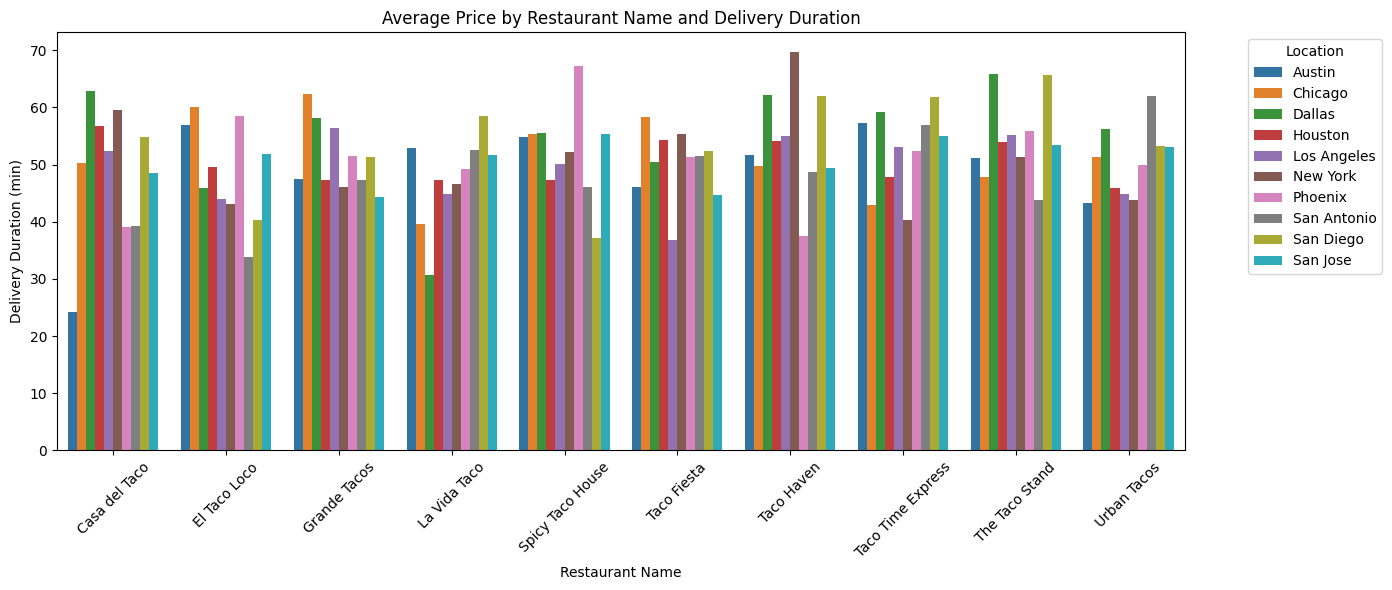

In [23]:
df_agg = df.groupby(['Restaurant Name', 'Location'])['Delivery Duration (min)'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=df_agg, x='Restaurant Name', y='Delivery Duration (min)', hue='Location')
plt.title('Average Price by Restaurant Name and Delivery Duration')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Location')
plt.tight_layout()
plt.show()

In [24]:
df

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order,Restaurant Name_code,Location_code,Delivery Duration,Restaurant Name by Location,Restaurant Name by Location_code
0,770487,El Taco Loco,New York,2024-08-01 14:55:00,2024-08-01 15:36:00,41,1,1,5,3.01,9.25,2.22,0,1,5,0 days 00:41:00,El Taco Loco - New York,15
1,671858,El Taco Loco,San Antonio,2024-11-23 17:11:00,2024-11-23 17:25:00,14,1,0,1,6.20,4.25,3.01,1,1,7,0 days 00:14:00,El Taco Loco - San Antonio,17
2,688508,Taco Haven,Austin,2024-11-21 20:24:00,2024-11-21 21:02:00,38,0,3,2,20.33,7.00,0.02,0,6,0,0 days 00:38:00,Taco Haven - Austin,60
3,944962,Spicy Taco House,Dallas,2024-09-21 06:43:00,2024-09-21 07:28:00,45,1,1,2,3.00,5.50,1.90,1,4,2,0 days 00:45:00,Spicy Taco House - Dallas,42
4,476417,Casa del Taco,San Antonio,2024-07-24 11:01:00,2024-07-24 11:16:00,15,0,3,0,24.34,4.50,1.14,0,0,7,0 days 00:15:00,Casa del Taco - San Antonio,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,164891,La Vida Taco,Austin,2024-05-27 11:12:00,2024-05-27 12:11:00,59,0,4,2,20.04,7.00,2.80,0,3,0,0 days 00:59:00,La Vida Taco - Austin,30
996,232442,The Taco Stand,San Antonio,2025-04-03 20:51:00,2025-04-03 21:29:00,38,1,2,0,13.69,3.00,1.38,0,8,7,0 days 00:38:00,The Taco Stand - San Antonio,87
997,251729,Urban Tacos,Houston,2025-01-23 05:33:00,2025-01-23 06:41:00,68,1,3,2,4.07,5.50,2.00,0,9,3,0 days 01:08:00,Urban Tacos - Houston,93
998,940215,Taco Fiesta,San Antonio,2024-09-05 15:49:00,2024-09-05 16:38:00,49,1,4,5,14.56,9.25,1.89,0,5,7,0 days 00:49:00,Taco Fiesta - San Antonio,57


In [25]:
# Restaurant Name by Location , Delivery Duration (min)
# Weekend Order , Restaurant Name by Location , Delivery Duration (min) 
# Distance , Restaurant Name by Location , Delivery Duration (min)
# Weekend Order , Restaurant Name by Location , Delivery Duration (min)

In [26]:
#salary , experience , education
#timeseries -> x-axis : Experience , y-axis:Salary , hue : Education

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

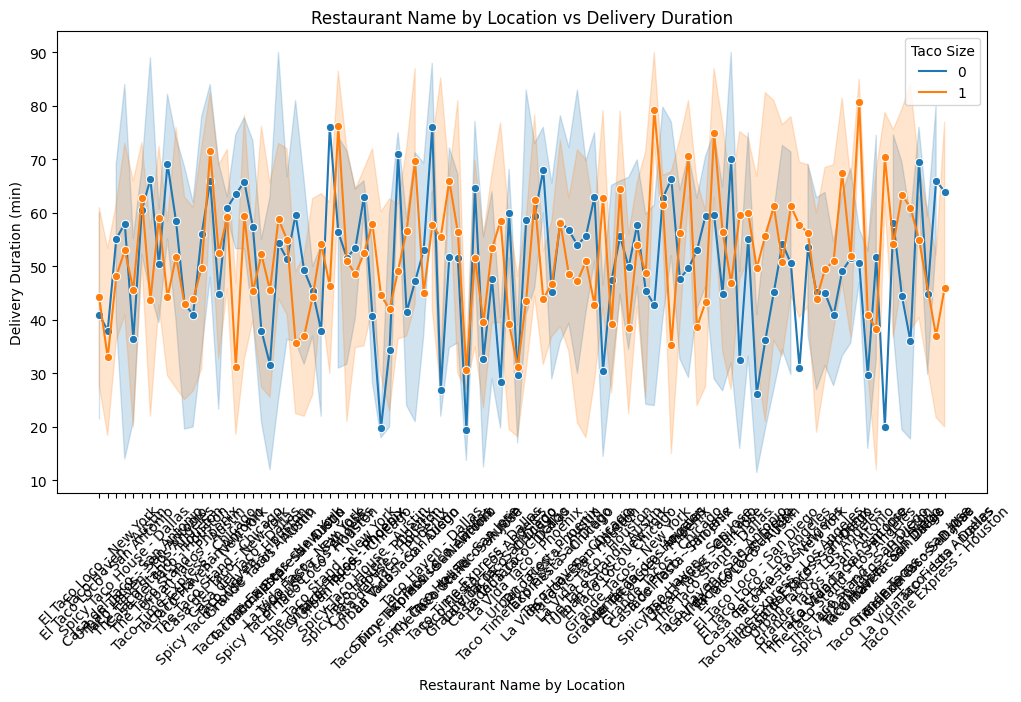

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Restaurant Name by Location' , y='Delivery Duration (min)',hue='Taco Size', marker='o')

plt.title("Restaurant Name by Location vs Delivery Duration")
plt.xlabel("Restaurant Name by Location")
plt.ylabel("Delivery Duration (min)")
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

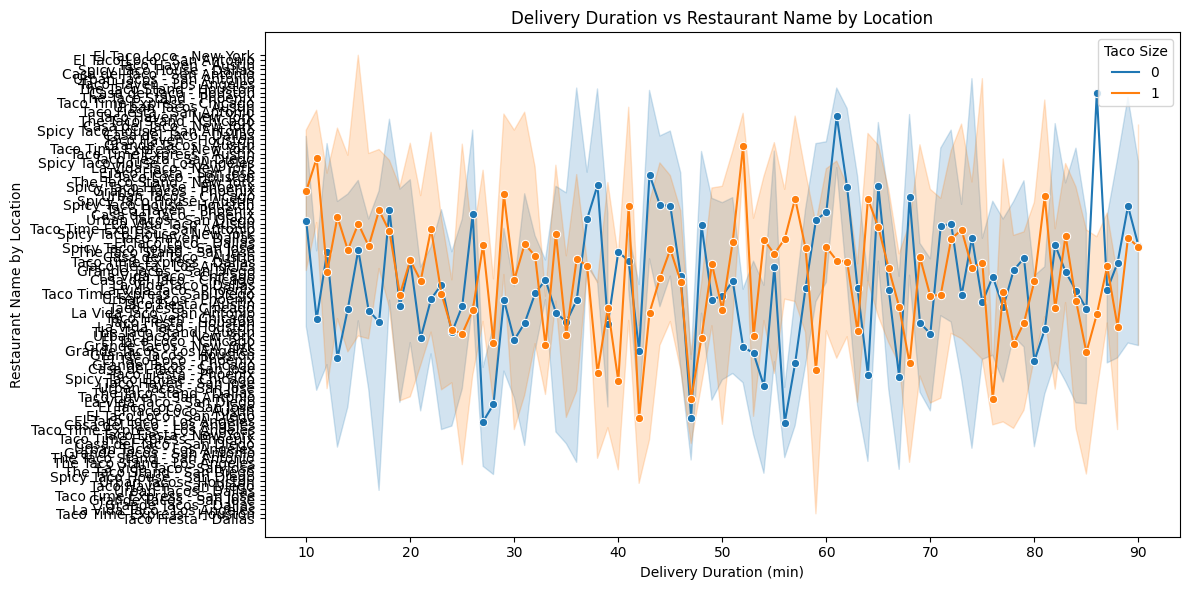

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Delivery Duration (min)', y='Restaurant Name by Location', hue='Taco Size', marker='o')
plt.title("Delivery Duration vs Restaurant Name by Location")
plt.xlabel("Delivery Duration (min)")
plt.ylabel("Restaurant Name by Location")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_49/1043872764.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/pytho

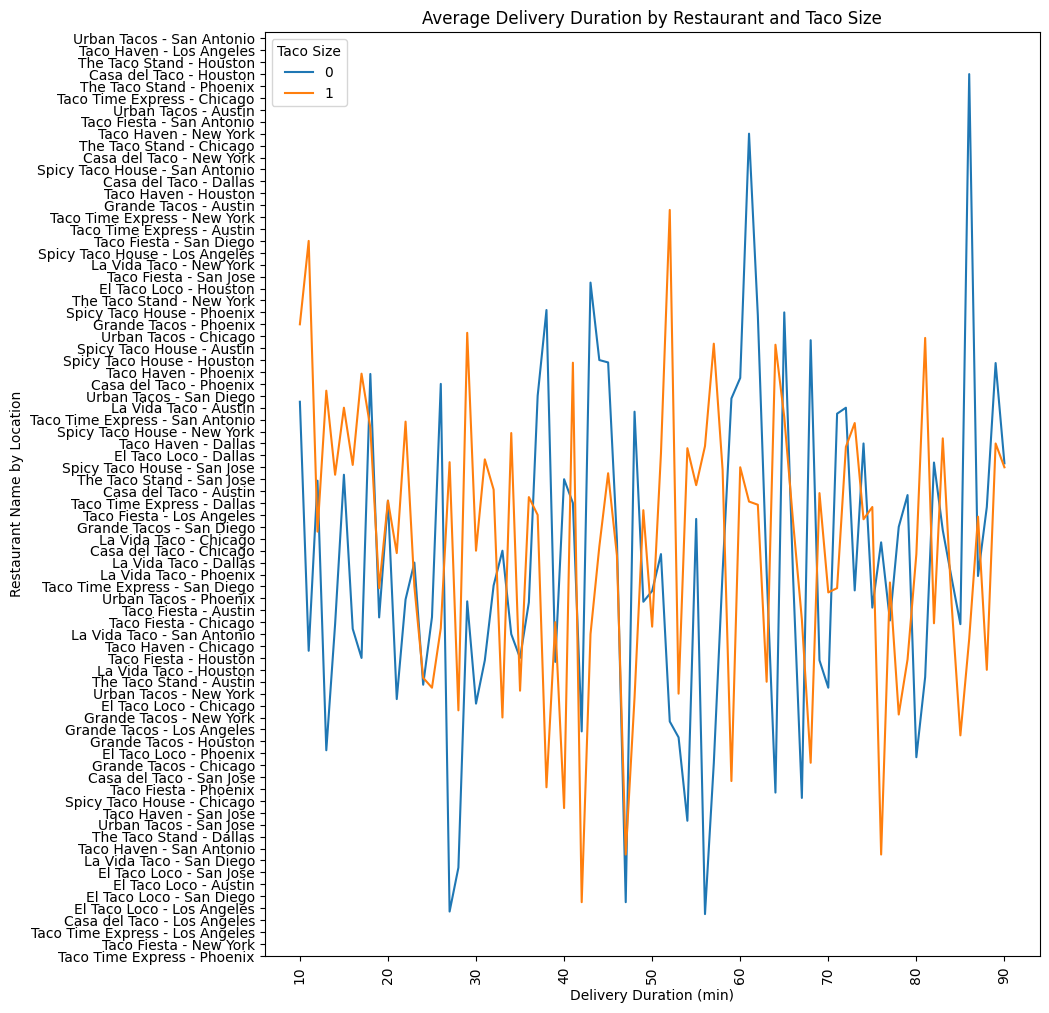

In [29]:
# Location , Restaurant Name , Delivery Duration (min)
#Restaurant Name by Location , Delivery Duration (min) , Taco Size-> line plot

order = df["Restaurant Name by Location"].unique()
plt.figure(figsize=(10, 12))
sns.lineplot(
    data=df,
    x="Delivery Duration (min)",
    y="Restaurant Name by Location",
    hue="Taco Size",
    estimator="mean",
    ci=None
)

plt.xticks(rotation=90)
plt.title("Average Delivery Duration by Restaurant and Taco Size")
plt.show()

In [30]:
"""
import plotly.express as px

fig = px.bar(
    df,
    x="Delivery Duration (min)",
    y="Restaurant Name by Location",
    color="Taco Size",
    title="Delivery Duration Distribution by Restaurant and Taco Size"
)
fig.update_layout(
    width=800,   # increase width
    height=2400   # increase height
)

fig.show()
"""

'\nimport plotly.express as px\n\nfig = px.bar(\n    df,\n    x="Delivery Duration (min)",\n    y="Restaurant Name by Location",\n    color="Taco Size",\n    title="Delivery Duration Distribution by Restaurant and Taco Size"\n)\nfig.update_layout(\n    width=800,   # increase width\n    height=2400   # increase height\n)\n\nfig.show()\n'

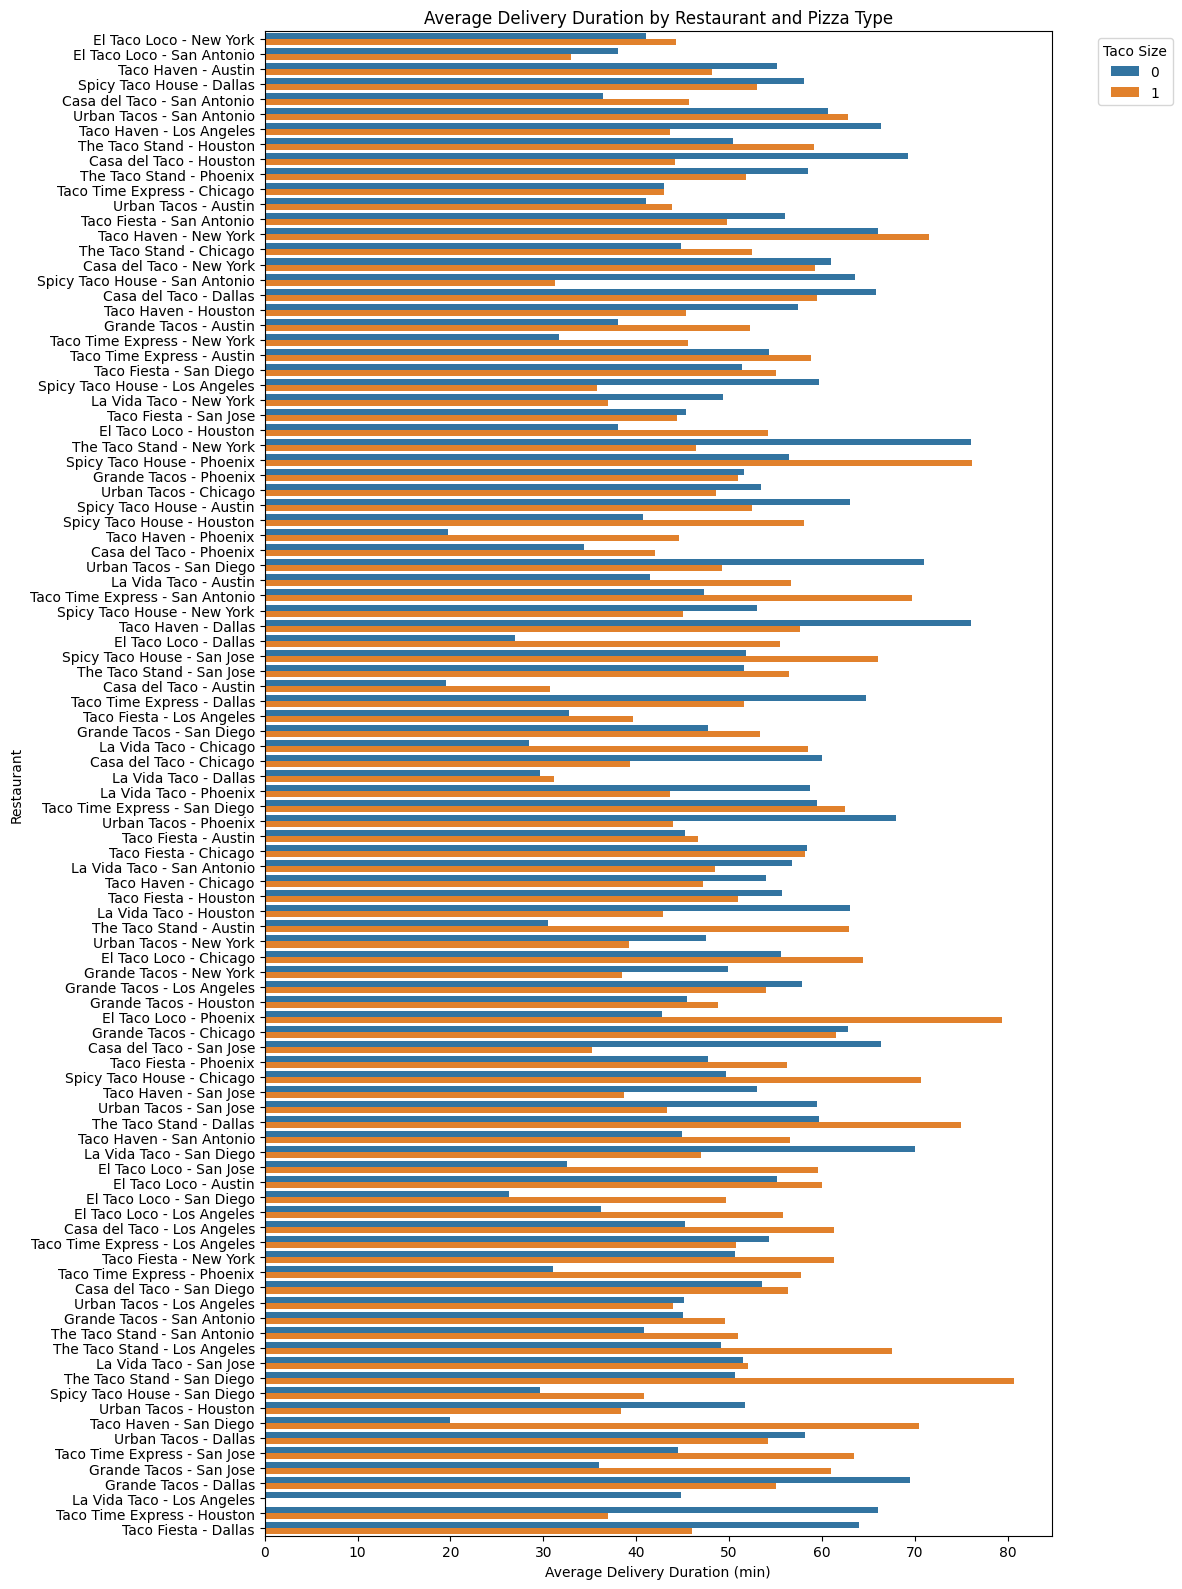

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 16))

sns.barplot(
    data=df,
    x="Delivery Duration (min)",
    y="Restaurant Name by Location",
    hue="Taco Size",
    estimator="mean",
    errorbar=None
)

plt.title("Average Delivery Duration by Restaurant and Pizza Type")
plt.ylabel("Restaurant")
plt.xlabel("Average Delivery Duration (min)")
plt.legend(title="Taco Size", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [32]:
#Restaurant Name by Location , Delivery Duration (min) , Taco Type -> line plot
import plotly.express as px

fig = px.box(
    df,
    x="Delivery Duration (min)",
    y="Restaurant Name by Location",
    color="Taco Type",
    title="Delivery Duration Distribution by Restaurant and Taco Size"
)
fig.update_layout(
    width=800,   # increase width
    height=2400   # increase height
)

fig.show()

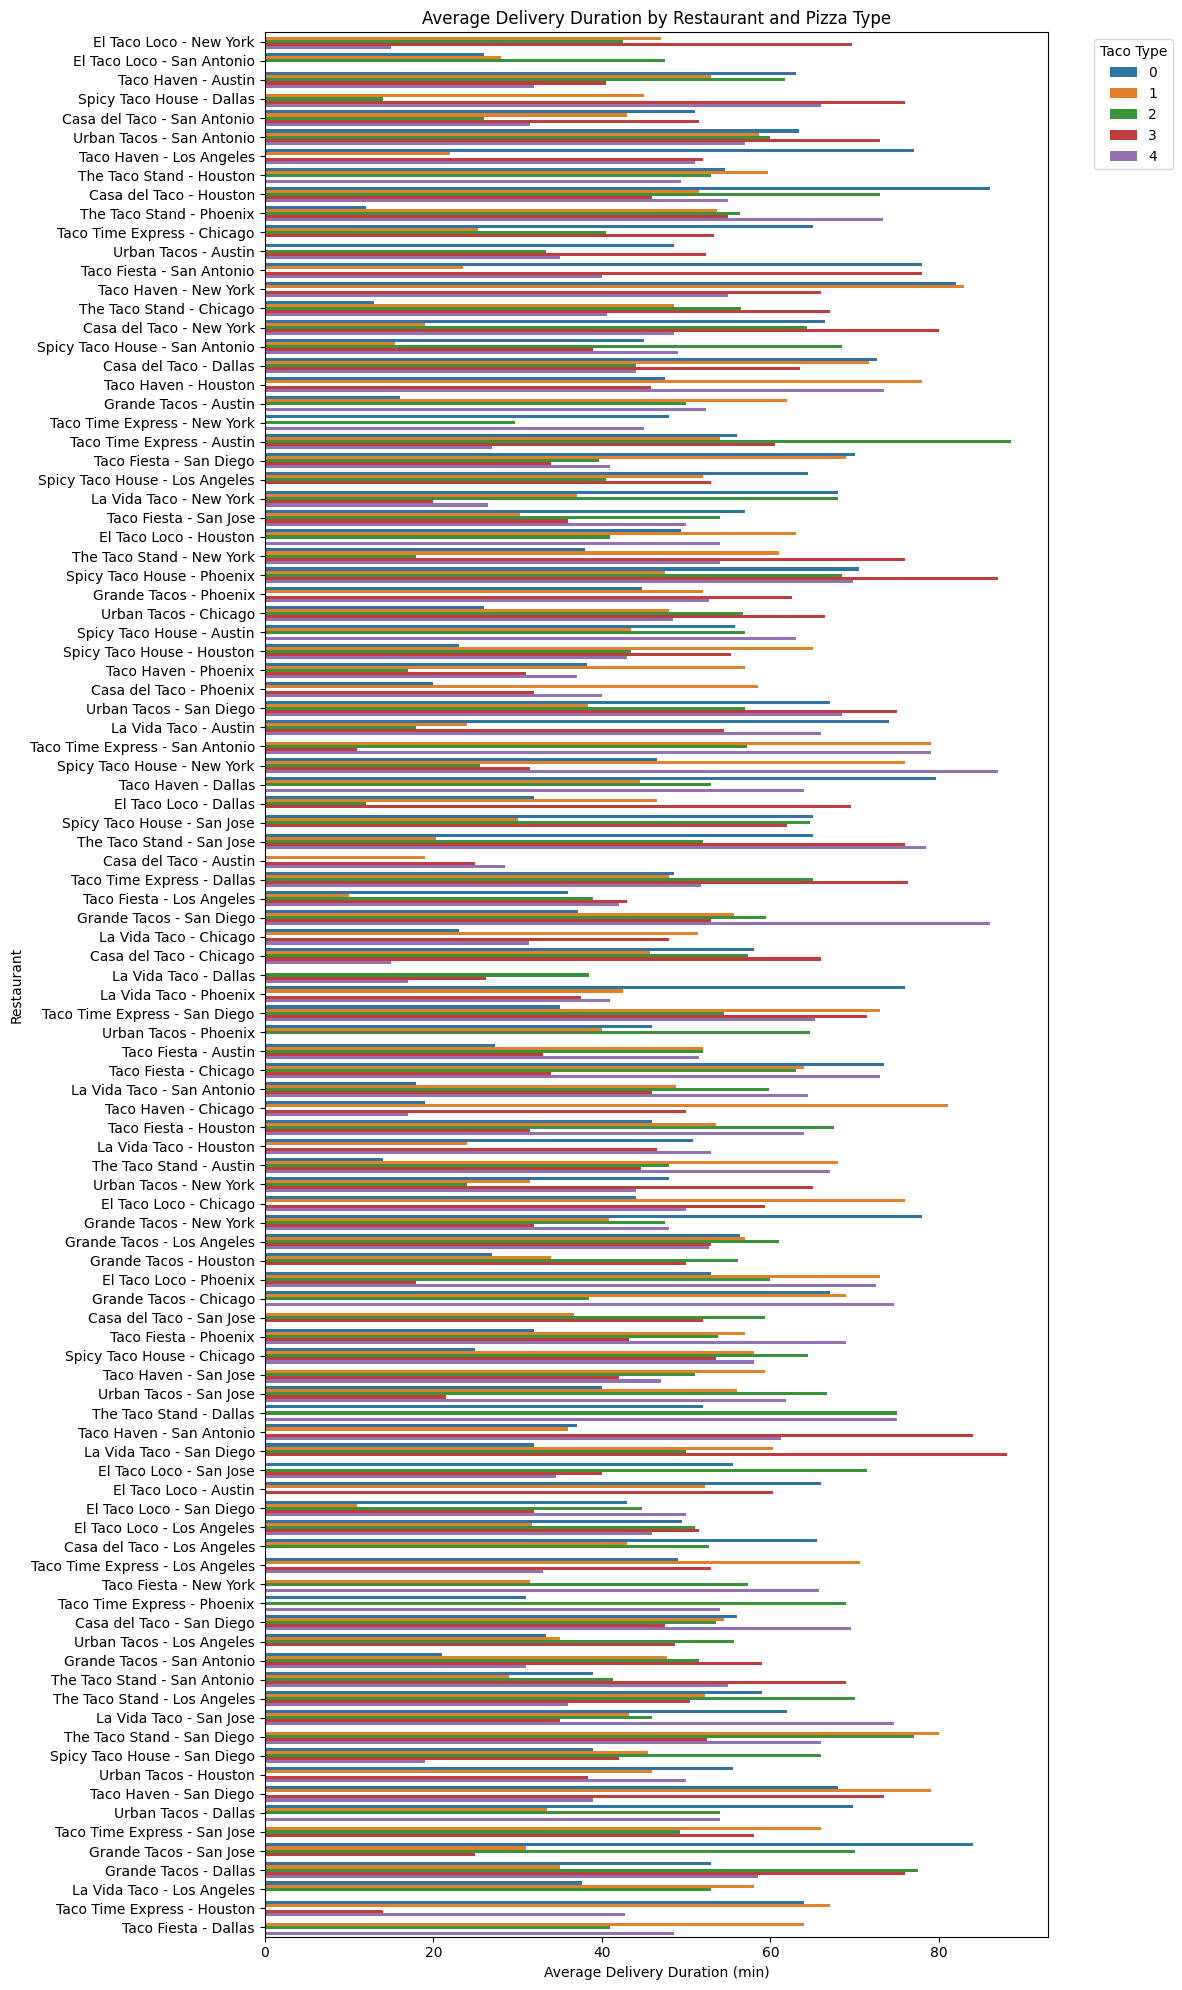

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 20))

sns.barplot(
    data=df,
    x="Delivery Duration (min)",
    y="Restaurant Name by Location",
    hue="Taco Type",
    estimator="mean",
    errorbar=None
)

plt.title("Average Delivery Duration by Restaurant and Pizza Type")
plt.ylabel("Restaurant")
plt.xlabel("Average Delivery Duration (min)")
plt.legend(title="Taco Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

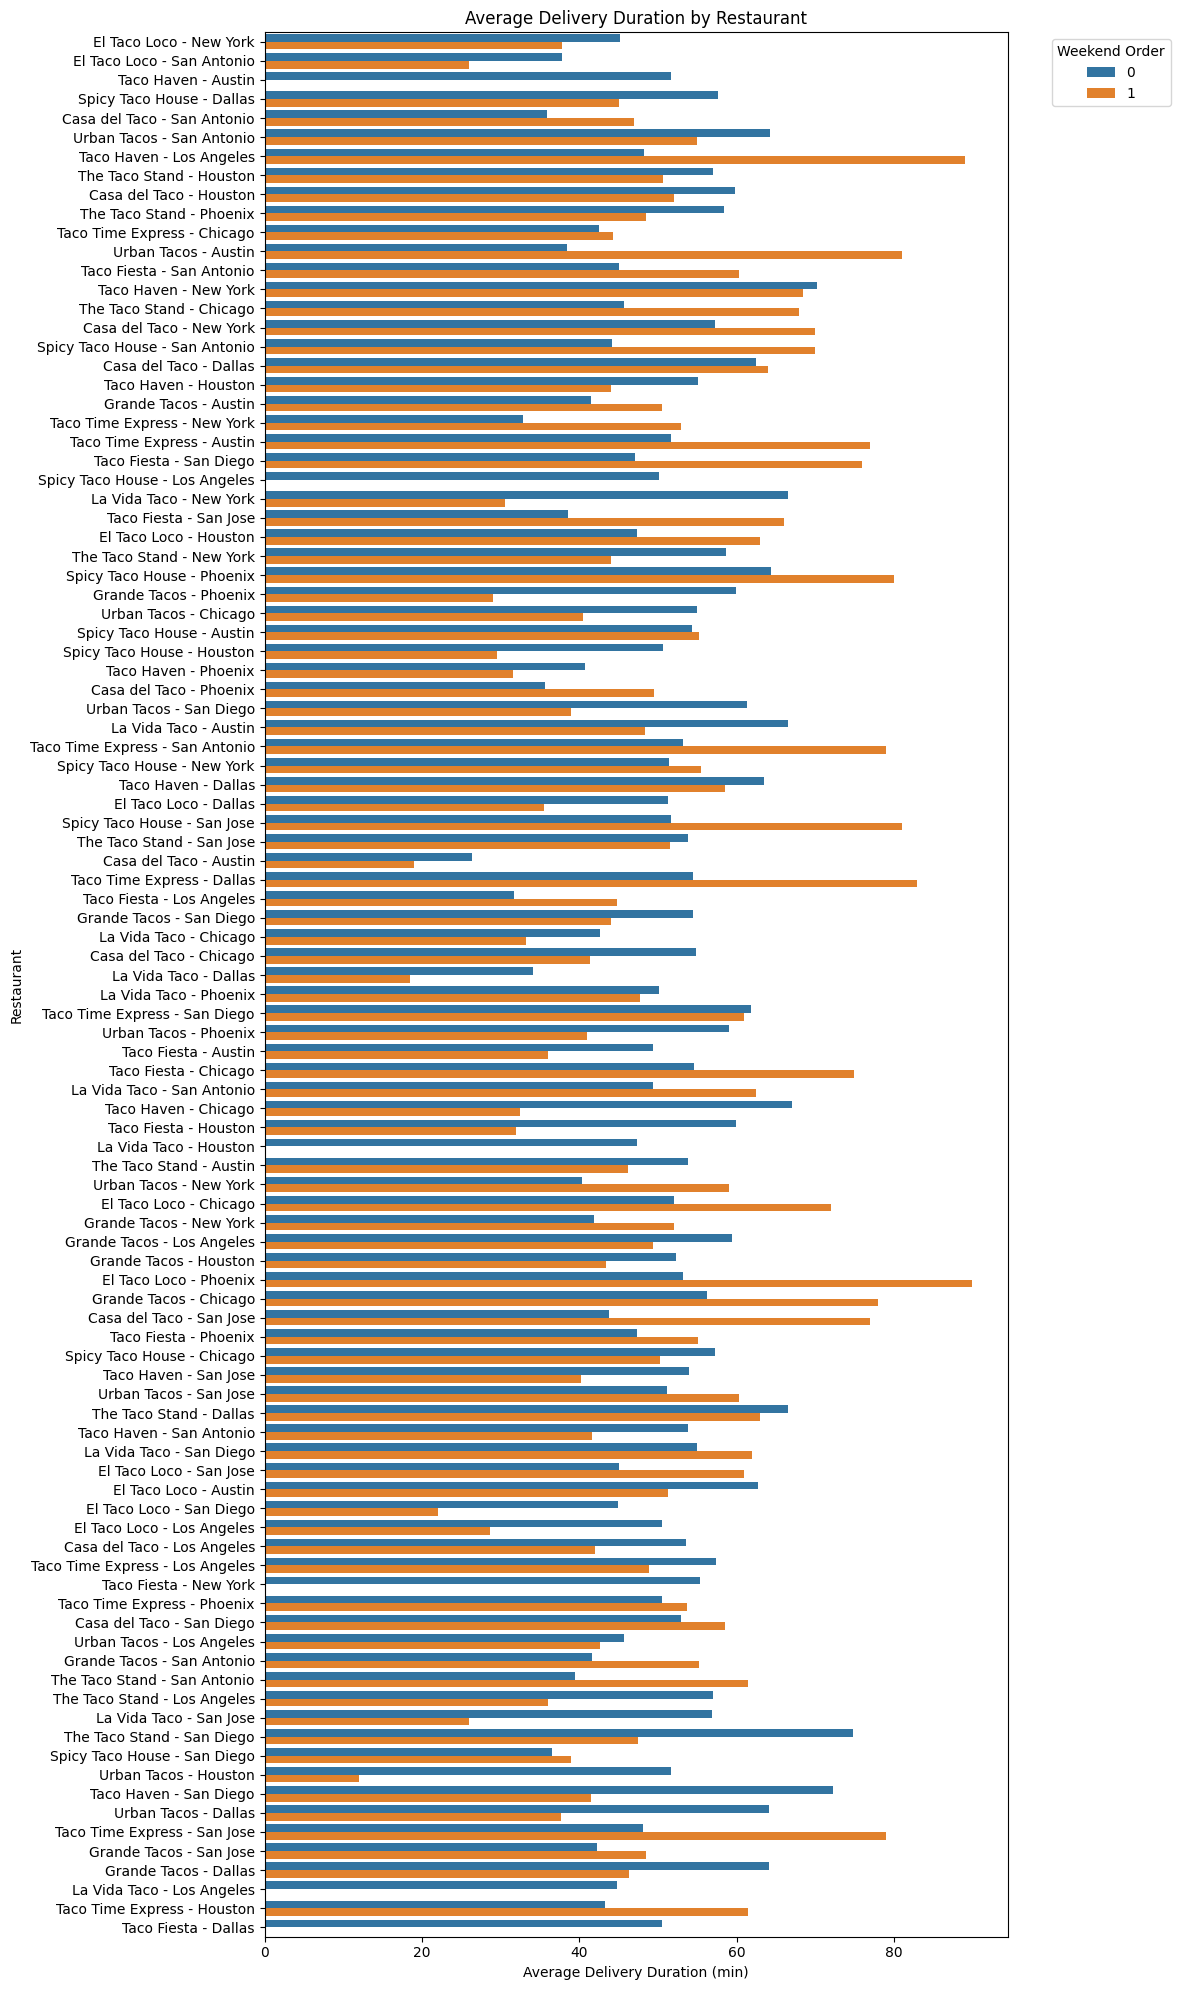

In [34]:
# Weekend Order , Restaurant Name by Location , Delivery Duration (min) 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 20))

sns.barplot(
    data=df,
    x="Delivery Duration (min)",
    y="Restaurant Name by Location",
    hue="Weekend Order",
    estimator="mean",
    errorbar=None
)

plt.title("Average Delivery Duration by Restaurant")
plt.ylabel("Restaurant")
plt.xlabel("Average Delivery Duration (min)")
plt.legend(title="Weekend Order", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [35]:
# Restaurant Name by Location , Delivery Duration (min) , Price ($)
"""
import plotly.express as px

fig = px.box(
    df,
    x="Price ($)",
    y="Delivery Duration (min)",
    color="Restaurant Name by Location",
    title="Delivery Duration Distribution by Restaurant and Taco Size"
)

fig.update_layout(
    width=2400,   # increase width
    height=800   # increase height
)

fig.show()
"""

'\nimport plotly.express as px\n\nfig = px.box(\n    df,\n    x="Price ($)",\n    y="Delivery Duration (min)",\n    color="Restaurant Name by Location",\n    title="Delivery Duration Distribution by Restaurant and Taco Size"\n)\n\nfig.update_layout(\n    width=2400,   # increase width\n    height=800   # increase height\n)\n\nfig.show()\n'

In [36]:
# Restaurant Name by Location , Delivery Duration (min) , Price ($)
# Weekend Order , Restaurant Name by Location , Delivery Duration (min) , Price ($)

# Distance , Restaurant Name by Location , Delivery Duration (min) , Price ($)
# 

In [37]:
# Restaurant Name by Location , Delivery Duration (min) , Price ($)
import plotly.graph_objects as go
import pandas as pd

#df['Combined_Category'] = df['Job_Title'].astype(str) + ' | ' + df['Education'].astype(str)

category_order = df.groupby('Restaurant Name by Location')['Price ($)'].median().sort_values(ascending=False).index

fig = go.Figure()

for category in category_order:
    category_data = df[df['Restaurant Name by Location'] == category]
    
    fig.add_trace(go.Box(
        y=category_data['Price ($)'],
        name=category,
        boxmean='sd',
        hovertemplate='<b>%{fullData.name}</b><br>' +
                      'Salary: $%{y:.2f}<br>' +
                      '<extra></extra>'
    ))

fig.update_layout(
    title='Salary Distribution: Restaurant Name by Location',
    yaxis_title='Price ($)',
    xaxis_title='Restaurant Name by Location',
    xaxis_tickangle=90,
    height=700,
    width=1800,
    showlegend=False
)

fig.show()

In [38]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

category_order = df.groupby('Restaurant Name by Location')['Price ($)'].median().sort_values(ascending=False).index

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Price Distribution by Restaurant & Location', 
                    'Delivery Duration by Restaurant & Location'),
    vertical_spacing=0.12,
    row_heights=[0.5, 0.5]
)

for category in category_order:
    category_data = df[df['Restaurant Name by Location'] == category]
    
    fig.add_trace(go.Box(
        y=category_data['Price ($)'],
        name=category,
        boxmean='sd',
        hovertemplate='<b>%{fullData.name}</b><br>' +
                      'Price: $%{y:.2f}<br>' +
                      '<extra></extra>',
        legendgroup=category,
        showlegend=False
    ), row=1, col=1)

for category in category_order:
    category_data = df[df['Restaurant Name by Location'] == category]
    
    fig.add_trace(go.Box(
        y=category_data['Delivery Duration (min)'],
        name=category,
        boxmean='sd',
        hovertemplate='<b>%{fullData.name}</b><br>' +
                      'Duration: %{y:.1f} min<br>' +
                      '<extra></extra>',
        legendgroup=category,
        showlegend=False
    ), row=2, col=1)

fig.update_layout(
    title_text='Price & Delivery Duration Distribution by Restaurant & Location',
    height=900,
    width=1800,
    showlegend=False
)

fig.update_yaxes(title_text='Price ($)', row=1, col=1)
fig.update_yaxes(title_text='Delivery Duration (min)', row=2, col=1)

fig.update_xaxes(title_text='Restaurant Name by Location', tickangle=90, row=1, col=1)
fig.update_xaxes(title_text='Restaurant Name by Location', tickangle=90, row=2, col=1)

fig.show()

In [39]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

category_order = df.groupby('Restaurant Name by Location')['Price ($)'].median().sort_values(ascending=False).index

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Price Distribution by Restaurant & Location', 
                    'Delivery Duration by Restaurant & Location'),
    vertical_spacing=0.12,
    row_heights=[0.5, 0.5]
)

for category in category_order:
    category_data = df[df['Restaurant Name by Location'] == category]
    
    fig.add_trace(go.Box(
        y=category_data['Price ($)'],
        name=category,
        boxmean='sd',
        hovertemplate='<b>%{fullData.name}</b><br>' +
                      'Price: $%{y:.2f}<br>' +
                      '<extra></extra>',
        legendgroup=category,
        showlegend=False
    ))
    fig.add_trace(go.Box(
        y=category_data['Delivery Duration (min)'],
        name=category,
        boxmean='sd',
        hovertemplate='<b>%{fullData.name}</b><br>' +
                      'Duration: %{y:.1f} min<br>' +
                      '<extra></extra>',
        legendgroup=category,
        showlegend=False
    ))

fig.update_layout(
    title_text='Price & Delivery Duration Distribution by Restaurant & Location',
    height=900,
    width=1800,
    showlegend=False
)

fig.update_yaxes(title_text='Price ($)', row=1, col=1)
fig.update_yaxes(title_text='Delivery Duration (min)', row=2, col=1)

fig.update_xaxes(title_text='Restaurant Name by Location', tickangle=90, row=1, col=1)
fig.update_xaxes(title_text='Restaurant Name by Location', tickangle=90, row=2, col=1)

fig.show()

In [40]:
import plotly.graph_objects as go
import pandas as pd

avg_data = df.groupby('Restaurant Name by Location').agg({
    'Price ($)': 'mean',
    'Delivery Duration (min)': 'mean'
}).reset_index()

avg_data = avg_data.sort_values('Price ($)', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=avg_data['Restaurant Name by Location'],
    y=avg_data['Price ($)'],
    name='Price ($)',
    marker_color='steelblue',
    hovertemplate='<b>%{x}</b><br>' +
                  'Avg Price: $%{y:.2f}<br>' +
                  '<extra></extra>'
))

fig.add_trace(go.Bar(
    x=avg_data['Restaurant Name by Location'],
    y=avg_data['Delivery Duration (min)'],
    name='Delivery Duration (min)',
    marker_color='coral',
    hovertemplate='<b>%{x}</b><br>' +
                  'Avg Duration: %{y:.1f} min<br>' +
                  '<extra></extra>'
))

fig.update_layout(
    title='Average Price & Delivery Duration by Restaurant & Location',
    xaxis_title='Restaurant Name by Location',
    yaxis_title='Value',
    xaxis_tickangle=90,
    barmode='group',
    height=700,
    width=1800,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()
"""
# Alternative: Normalized view (if scales are too different)
print("\n" + "="*60)
print("NORMALIZED VIEW (0-100 scale)")
print("="*60)

# Normalize to 0-100 scale
avg_data['Price_Normalized'] = (avg_data['Price ($)'] / avg_data['Price ($)'].max()) * 100
avg_data['Duration_Normalized'] = (avg_data['Delivery Duration (min)'] / avg_data['Delivery Duration (min)'].max()) * 100

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=avg_data['Restaurant Name by Location'],
    y=avg_data['Price_Normalized'],
    name='Price (Normalized)',
    marker_color='steelblue',
    hovertemplate='<b>%{x}</b><br>' +
                  'Price Score: %{y:.1f}/100<br>' +
                  'Actual Price: $' + avg_data['Price ($)'].astype(str) + '<br>' +
                  '<extra></extra>'
))

fig2.add_trace(go.Bar(
    x=avg_data['Restaurant Name by Location'],
    y=avg_data['Duration_Normalized'],
    name='Delivery Duration (Normalized)',
    marker_color='coral',
    hovertemplate='<b>%{x}</b><br>' +
                  'Duration Score: %{y:.1f}/100<br>' +
                  'Actual Duration: ' + avg_data['Delivery Duration (min)'].round(1).astype(str) + ' min<br>' +
                  '<extra></extra>'
))

fig2.update_layout(
    title='Normalized Price & Delivery Duration Comparison (0-100 Scale)',
    xaxis_title='Restaurant Name by Location',
    yaxis_title='Normalized Score (0-100)',
    xaxis_tickangle=90,
    barmode='group',
    height=700,
    width=1800,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig2.show()

print("\n✓ Bar charts created!")
"""

'\n# Alternative: Normalized view (if scales are too different)\nprint("\n" + "="*60)\nprint("NORMALIZED VIEW (0-100 scale)")\nprint("="*60)\n\n# Normalize to 0-100 scale\navg_data[\'Price_Normalized\'] = (avg_data[\'Price ($)\'] / avg_data[\'Price ($)\'].max()) * 100\navg_data[\'Duration_Normalized\'] = (avg_data[\'Delivery Duration (min)\'] / avg_data[\'Delivery Duration (min)\'].max()) * 100\n\nfig2 = go.Figure()\n\nfig2.add_trace(go.Bar(\n    x=avg_data[\'Restaurant Name by Location\'],\n    y=avg_data[\'Price_Normalized\'],\n    name=\'Price (Normalized)\',\n    marker_color=\'steelblue\',\n    hovertemplate=\'<b>%{x}</b><br>\' +\n                  \'Price Score: %{y:.1f}/100<br>\' +\n                  \'Actual Price: $\' + avg_data[\'Price ($)\'].astype(str) + \'<br>\' +\n                  \'<extra></extra>\'\n))\n\nfig2.add_trace(go.Bar(\n    x=avg_data[\'Restaurant Name by Location\'],\n    y=avg_data[\'Duration_Normalized\'],\n    name=\'Delivery Duration (Normalized)\',\n    

In [41]:
"""
import plotly.graph_objects as go
import pandas as pd

# Sort by median price for better visualization
category_order = df.groupby('Restaurant Name by Location')['Price ($)'].median().sort_values(ascending=False).index

# Create figure
fig = go.Figure()

# Add Price box plots
for i, category in enumerate(category_order):
    category_data = df[df['Restaurant Name by Location'] == category]
    
    fig.add_trace(go.Box(
        x=[f"{category} - Price"] * len(category_data),
        y=category_data['Price ($)'],
        name='Price ($)',
        boxmean='sd',
        marker_color='steelblue',
        legendgroup='price',
        showlegend=(i == 0),  # Only show legend once
        hovertemplate='<b>%{x}</b><br>' +
                      'Price: $%{y:.2f}<br>' +
                      '<extra></extra>'
    ))

# Add Delivery Duration box plots
for i, category in enumerate(category_order):
    category_data = df[df['Restaurant Name by Location'] == category]
    
    fig.add_trace(go.Box(
        x=[f"{category} - Duration"] * len(category_data),
        y=category_data['Delivery Duration (min)'],
        name='Delivery Duration (min)',
        boxmean='sd',
        marker_color='coral',
        legendgroup='duration',
        showlegend=(i == 0),  # Only show legend once
        hovertemplate='<b>%{x}</b><br>' +
                      'Duration: %{y:.1f} min<br>' +
                      '<extra></extra>'
    ))

# Update layout
fig.update_layout(
    title='Price & Delivery Duration Distribution by Restaurant & Location',
    xaxis_title='Restaurant Name by Location',
    yaxis_title='Value',
    xaxis_tickangle=90,
    height=700,
    width=1800,
    boxmode='group',  # Group boxes side-by-side
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()

# Alternative: Separate Y-axes for better scaling
print("\n" + "="*60)
print("DUAL Y-AXIS VERSION")
print("="*60)

from plotly.subplots import make_subplots

fig2 = make_subplots(specs=[[{"secondary_y": True}]])

# Add Price boxes on primary y-axis
for category in category_order:
    category_data = df[df['Restaurant Name by Location'] == category]
    
    fig2.add_trace(
        go.Box(
            x=[category] * len(category_data),
            y=category_data['Price ($)'],
            name='Price ($)',
            boxmean='sd',
            marker_color='steelblue',
            legendgroup='price',
            showlegend=False,
            hovertemplate='<b>%{x}</b><br>' +
                          'Price: $%{y:.2f}<br>' +
                          '<extra></extra>'
        ),
        secondary_y=False
    )

# Add Duration boxes on secondary y-axis
for category in category_order:
    category_data = df[df['Restaurant Name by Location'] == category]
    
    fig2.add_trace(
        go.Box(
            x=[category] * len(category_data),
            y=category_data['Delivery Duration (min)'],
            name='Delivery Duration (min)',
            boxmean='sd',
            marker_color='coral',
            legendgroup='duration',
            showlegend=False,
            hovertemplate='<b>%{x}</b><br>' +
                          'Duration: %{y:.1f} min<br>' +
                          '<extra></extra>'
        ),
        secondary_y=True
    )

# Update axes
fig2.update_xaxes(title_text="Restaurant Name by Location", tickangle=90)
fig2.update_yaxes(title_text="Price ($)", secondary_y=False, color='steelblue')
fig2.update_yaxes(title_text="Delivery Duration (min)", secondary_y=True, color='coral')

fig2.update_layout(
    title='Price & Delivery Duration by Restaurant (Dual Y-Axis)',
    height=700,
    width=1800,
    boxmode='overlay'
)

fig2.show()

print("\n✓ Box plots created!")
"""

'\nimport plotly.graph_objects as go\nimport pandas as pd\n\n# Sort by median price for better visualization\ncategory_order = df.groupby(\'Restaurant Name by Location\')[\'Price ($)\'].median().sort_values(ascending=False).index\n\n# Create figure\nfig = go.Figure()\n\n# Add Price box plots\nfor i, category in enumerate(category_order):\n    category_data = df[df[\'Restaurant Name by Location\'] == category]\n    \n    fig.add_trace(go.Box(\n        x=[f"{category} - Price"] * len(category_data),\n        y=category_data[\'Price ($)\'],\n        name=\'Price ($)\',\n        boxmean=\'sd\',\n        marker_color=\'steelblue\',\n        legendgroup=\'price\',\n        showlegend=(i == 0),  # Only show legend once\n        hovertemplate=\'<b>%{x}</b><br>\' +\n                      \'Price: $%{y:.2f}<br>\' +\n                      \'<extra></extra>\'\n    ))\n\n# Add Delivery Duration box plots\nfor i, category in enumerate(category_order):\n    category_data = df[df[\'Restaurant Name by 

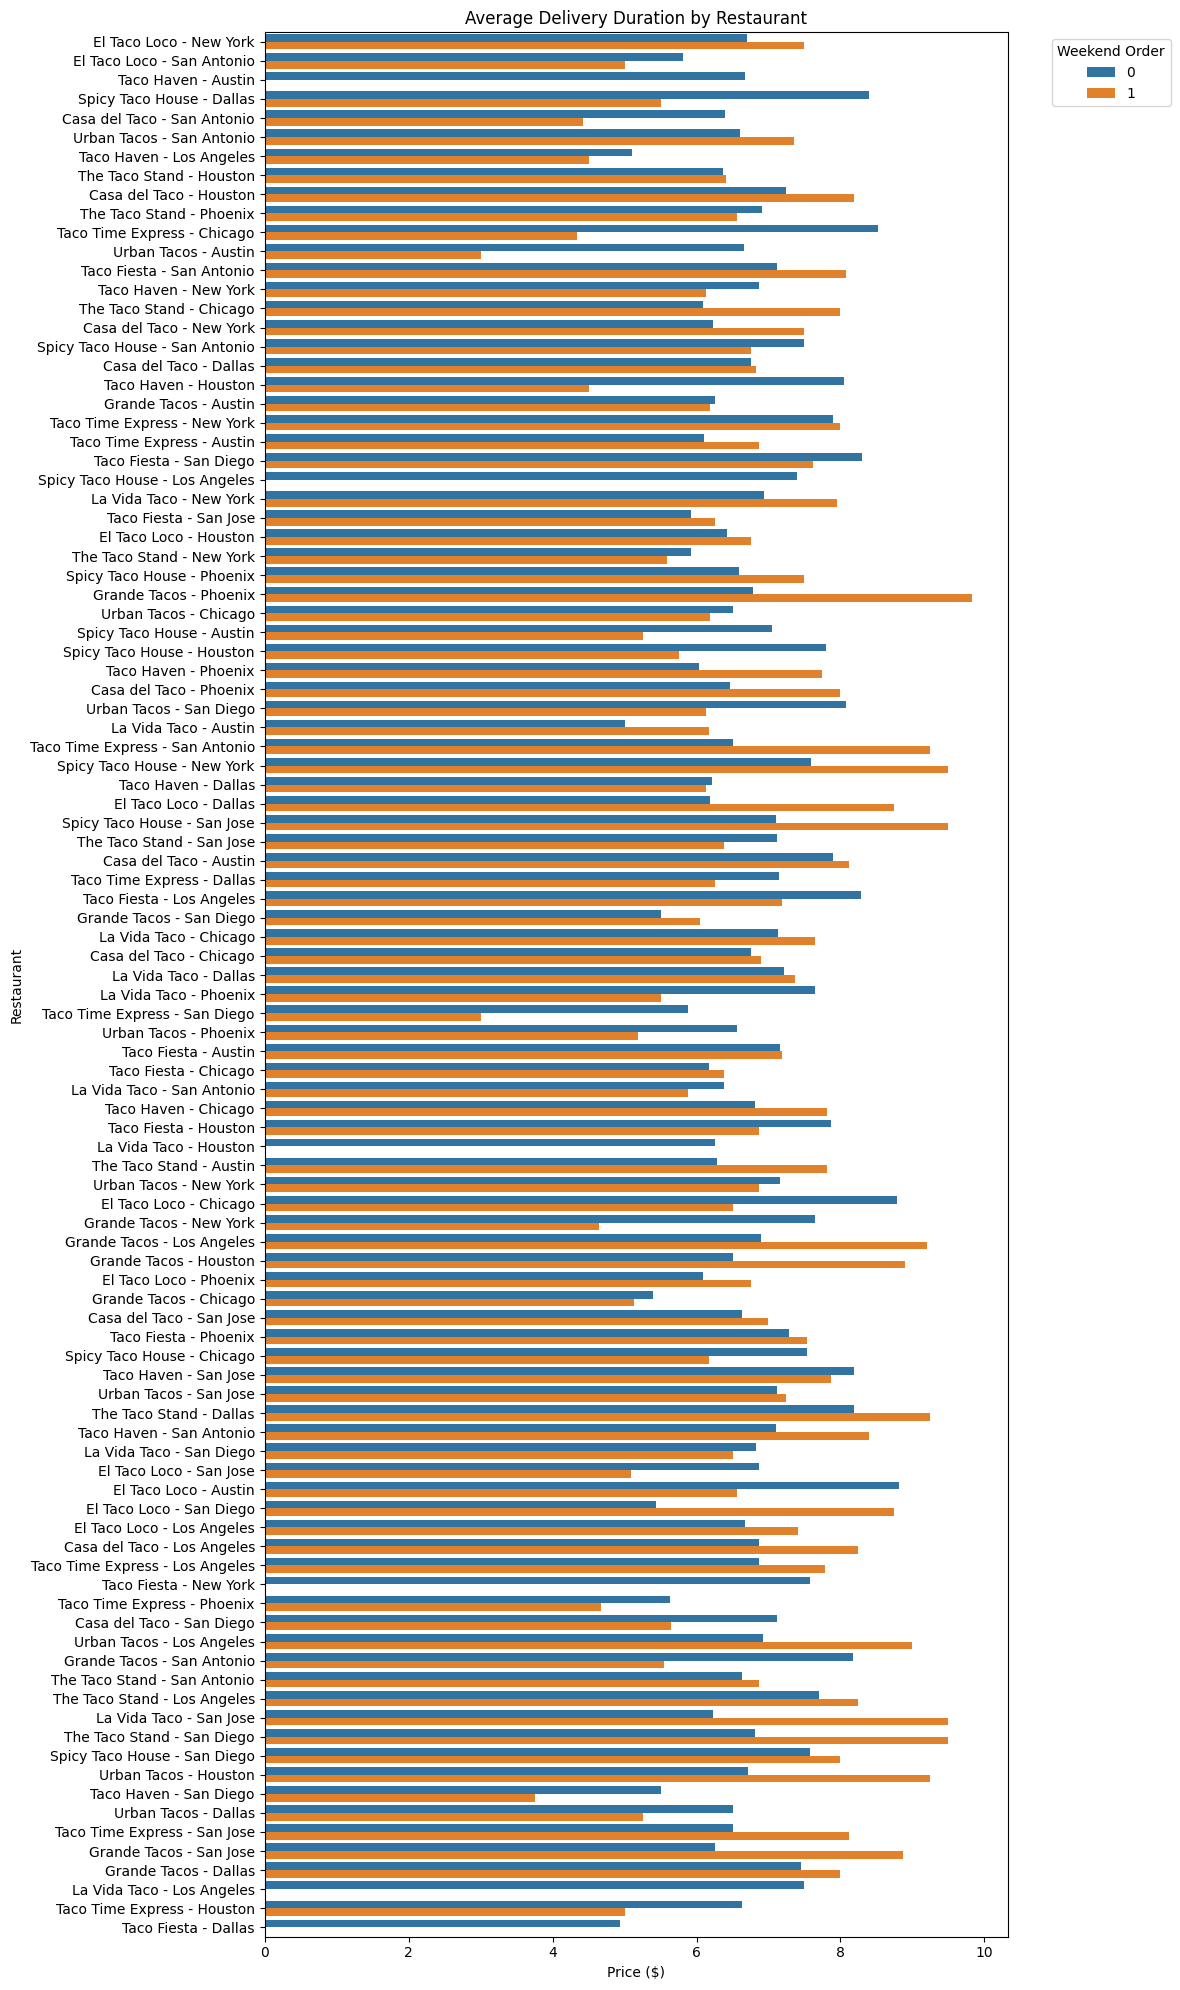

In [42]:
# Weekend Order , Restaurant Name by Location , Price ($)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 20))

sns.barplot(
    data=df,
    x="Price ($)",
    y="Restaurant Name by Location",
    hue="Weekend Order",
    estimator="mean",
    errorbar=None
)

plt.title("Average Delivery Duration by Restaurant")
plt.ylabel("Restaurant")
plt.xlabel("Price ($)")
plt.legend(title="Weekend Order", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [43]:
df

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order,Restaurant Name_code,Location_code,Delivery Duration,Restaurant Name by Location,Restaurant Name by Location_code
0,770487,El Taco Loco,New York,2024-08-01 14:55:00,2024-08-01 15:36:00,41,1,1,5,3.01,9.25,2.22,0,1,5,0 days 00:41:00,El Taco Loco - New York,15
1,671858,El Taco Loco,San Antonio,2024-11-23 17:11:00,2024-11-23 17:25:00,14,1,0,1,6.20,4.25,3.01,1,1,7,0 days 00:14:00,El Taco Loco - San Antonio,17
2,688508,Taco Haven,Austin,2024-11-21 20:24:00,2024-11-21 21:02:00,38,0,3,2,20.33,7.00,0.02,0,6,0,0 days 00:38:00,Taco Haven - Austin,60
3,944962,Spicy Taco House,Dallas,2024-09-21 06:43:00,2024-09-21 07:28:00,45,1,1,2,3.00,5.50,1.90,1,4,2,0 days 00:45:00,Spicy Taco House - Dallas,42
4,476417,Casa del Taco,San Antonio,2024-07-24 11:01:00,2024-07-24 11:16:00,15,0,3,0,24.34,4.50,1.14,0,0,7,0 days 00:15:00,Casa del Taco - San Antonio,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,164891,La Vida Taco,Austin,2024-05-27 11:12:00,2024-05-27 12:11:00,59,0,4,2,20.04,7.00,2.80,0,3,0,0 days 00:59:00,La Vida Taco - Austin,30
996,232442,The Taco Stand,San Antonio,2025-04-03 20:51:00,2025-04-03 21:29:00,38,1,2,0,13.69,3.00,1.38,0,8,7,0 days 00:38:00,The Taco Stand - San Antonio,87
997,251729,Urban Tacos,Houston,2025-01-23 05:33:00,2025-01-23 06:41:00,68,1,3,2,4.07,5.50,2.00,0,9,3,0 days 01:08:00,Urban Tacos - Houston,93
998,940215,Taco Fiesta,San Antonio,2024-09-05 15:49:00,2024-09-05 16:38:00,49,1,4,5,14.56,9.25,1.89,0,5,7,0 days 00:49:00,Taco Fiesta - San Antonio,57


In [44]:
df[['Taco Size' , 'Taco Type', 'Toppings Count' , 'Price ($)']]

,Taco Size,Taco Type,Toppings Count,Price ($)
0,1,1,5,9.25
1,1,0,1,4.25
2,0,3,2,7.00
3,1,1,2,5.50
4,0,3,0,4.50
...,...,...,...,...
995,0,4,2,7.00
996,1,2,0,3.00
997,1,3,2,5.50
998,1,4,5,9.25


In [45]:
# Toppings Count , Price ($)
# Taco Size , Price ($)
# Toppings Count , Taco Size , Taco Type , Price ($)
"""
df_taco_prop = df[['Taco Size','Taco Type','Toppings Count','Price ($)']].copy()
df_taco_prop
"""

"\ndf_taco_prop = df[['Taco Size','Taco Type','Toppings Count','Price ($)']].copy()\ndf_taco_prop\n"

In [46]:
#y-axis:Price ($) , hue:Taco Type / Taco Size , x-axis:Toppings Count


In [47]:
# df_selected -> price , tacosize , toppings count , Restaurant Name by Location
df_selected = df[['Restaurant Name by Location_code','Taco Size','Taco Type','Toppings Count','Price ($)']].copy()
df_selected

,Restaurant Name by Location_code,Taco Size,Taco Type,Toppings Count,Price ($)
0,15,1,1,5,9.25
1,17,1,0,1,4.25
2,60,0,3,2,7.00
3,42,1,1,2,5.50
4,7,0,3,0,4.50
...,...,...,...,...,...
995,30,0,4,2,7.00
996,87,1,2,0,3.00
997,93,1,3,2,5.50
998,57,1,4,5,9.25


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version

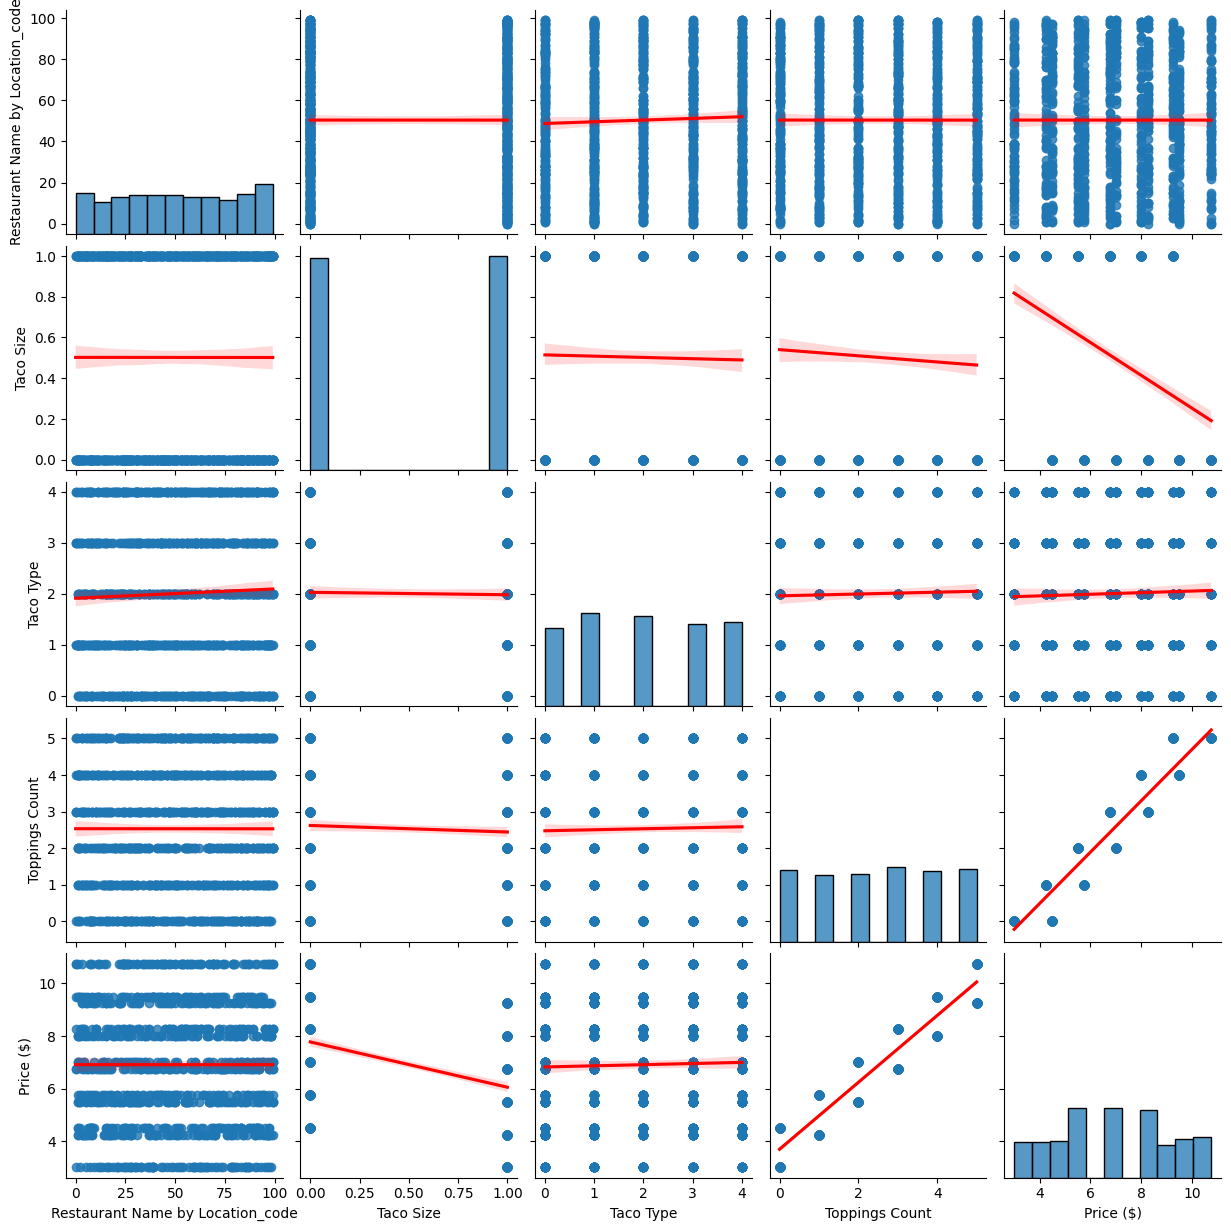

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add regression lines to all scatter plots
sns.pairplot(df_selected, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.show()

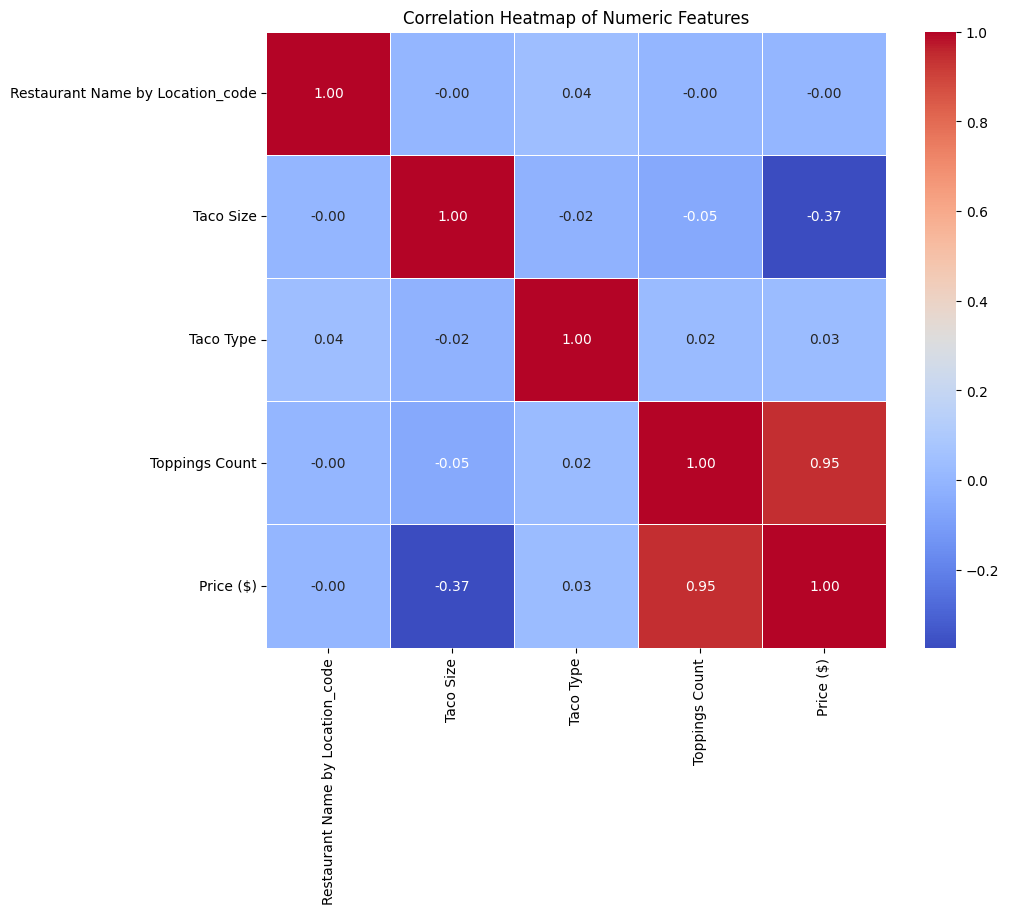

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Select only numeric columns
numeric_df = df_selected.select_dtypes(include=['number'])

# Step 2: Compute the correlation matrix
corr = numeric_df.corr()

# Step 3: Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [50]:
top_5_pairs = (
    corr.unstack()
    .dropna()
    .abs()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(5)
)

# Optional: convert to DataFrame for easier viewing
top_5_df = pd.DataFrame({
    'Feature 1': [i[0] for i in top_5_pairs.index],
    'Feature 2': [i[1] for i in top_5_pairs.index],
    'Correlation': [corr.loc[i[0], i[1]] for i in top_5_pairs.index]
})

print("\nTop 5 Most Correlated Feature Pairs:")
print(top_5_df)


Top 5 Most Correlated Feature Pairs:
                          Feature 1                         Feature 2  \
0  Restaurant Name by Location_code  Restaurant Name by Location_code   
1                         Price ($)                    Toppings Count   
2                         Taco Size                         Price ($)   
3                    Toppings Count                         Taco Size   
4                         Taco Type  Restaurant Name by Location_code   

   Correlation  
0     1.000000  
1     0.945928  
2    -0.373061  
3    -0.051928  
4     0.038849  


In [51]:
df_selected

,Restaurant Name by Location_code,Taco Size,Taco Type,Toppings Count,Price ($)
0,15,1,1,5,9.25
1,17,1,0,1,4.25
2,60,0,3,2,7.00
3,42,1,1,2,5.50
4,7,0,3,0,4.50
...,...,...,...,...,...
995,30,0,4,2,7.00
996,87,1,2,0,3.00
997,93,1,3,2,5.50
998,57,1,4,5,9.25


In [52]:
#'Toppings Count','Price ($)' , 'Restaurant Name by Location_code'
#'Toppings Count','Price ($)' , 'Taco Type'
#'Toppings Count','Price ($)' , 'Taco Size'

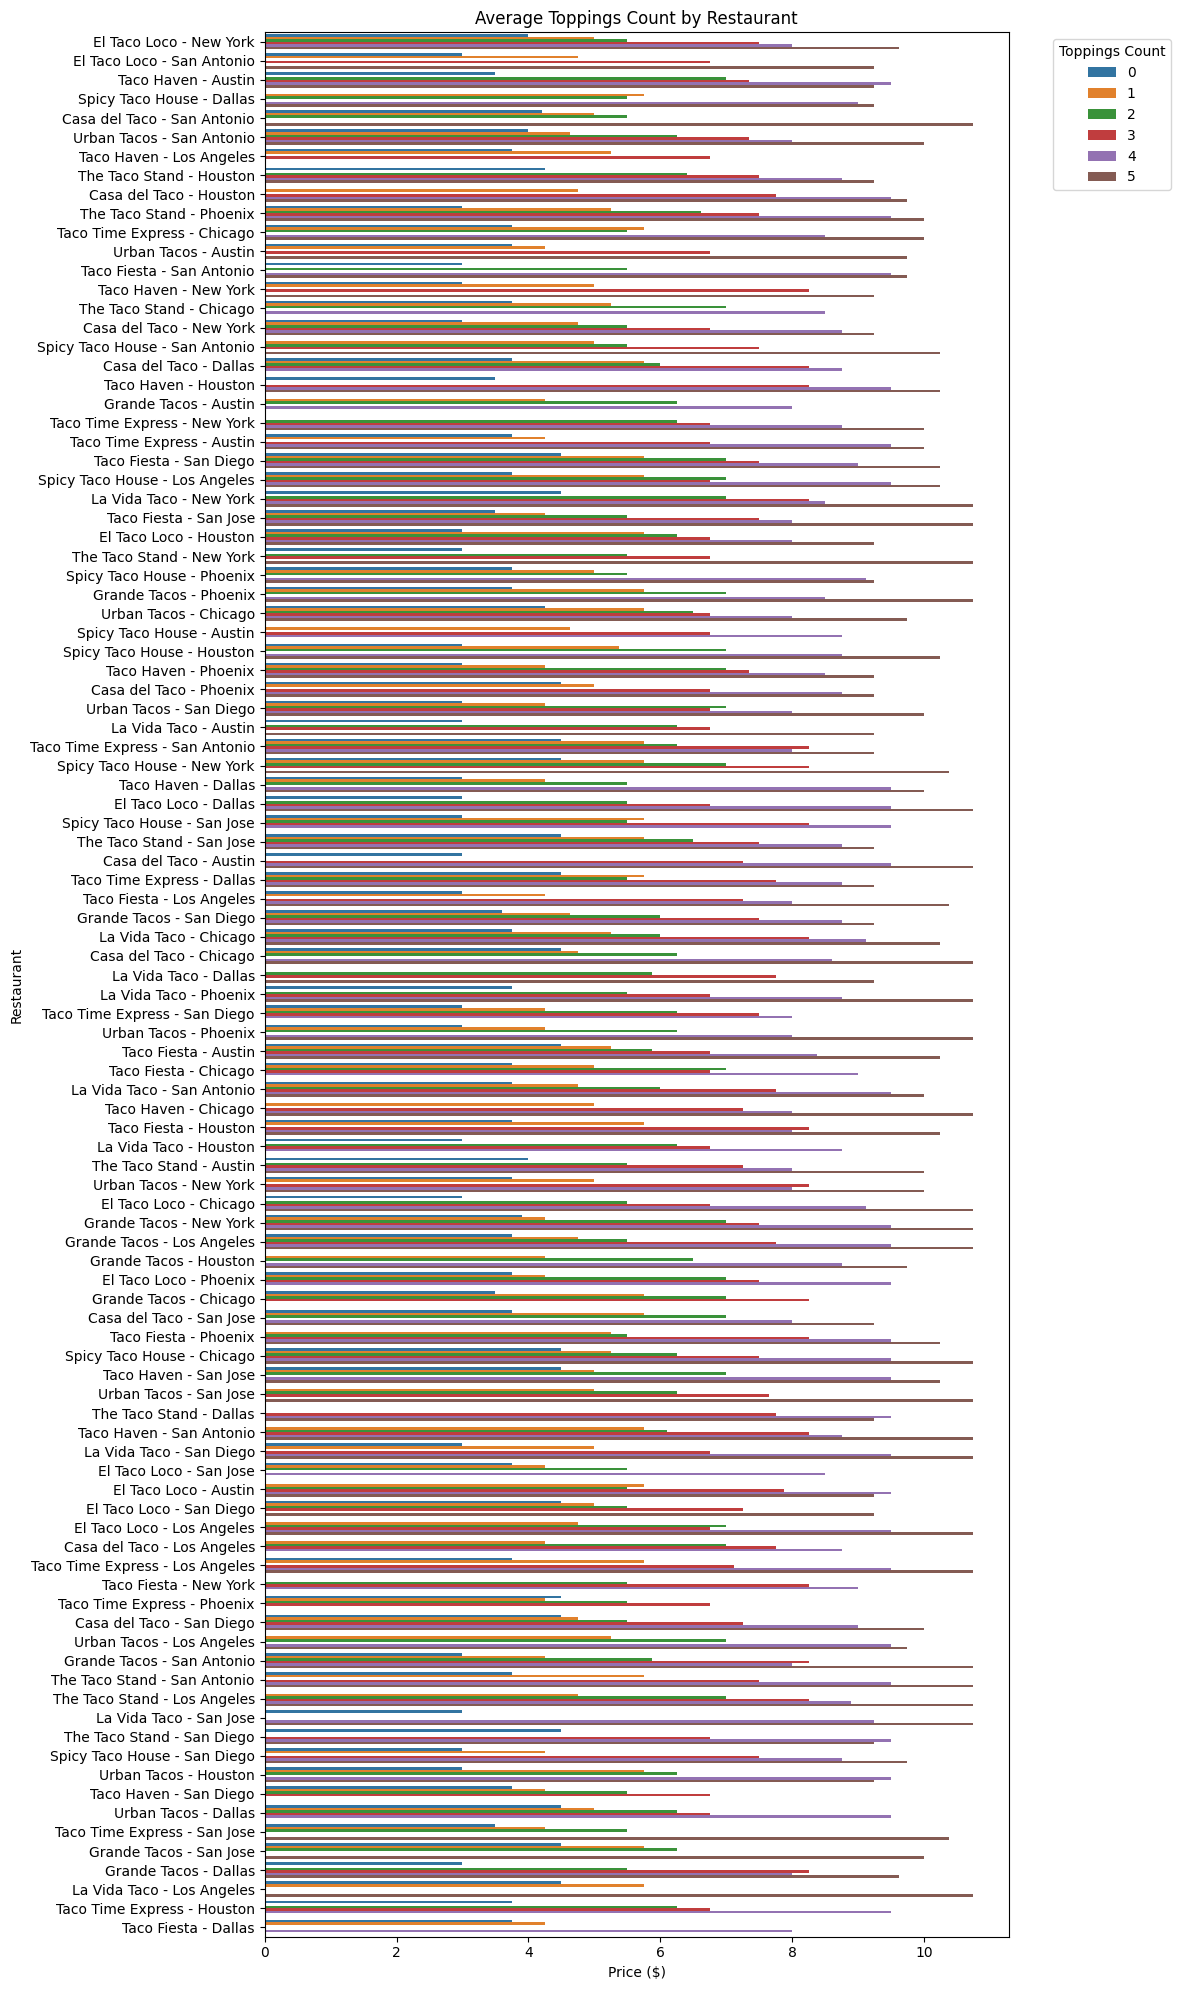

In [53]:
#'Toppings Count','Price ($)' , 'Restaurant Name by Location_code'
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 20))

sns.barplot(
    data=df,
    x="Price ($)",
    y="Restaurant Name by Location",
    hue="Toppings Count",
    estimator="mean",
    errorbar=None
)

plt.title("Average Toppings Count by Restaurant")
plt.ylabel("Restaurant")
plt.xlabel("Price ($)")
plt.legend(title="Toppings Count", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

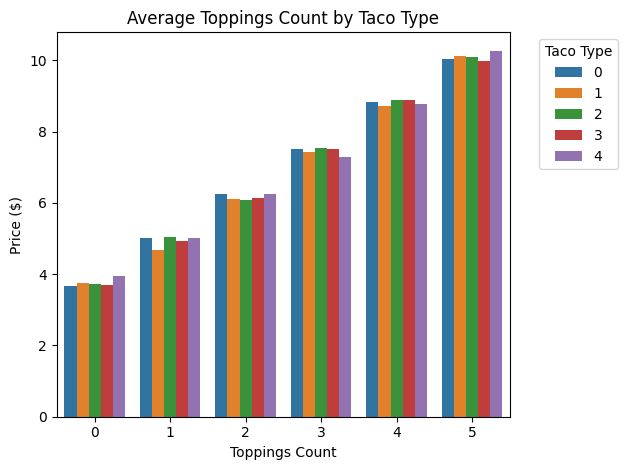

In [54]:
#'Toppings Count','Price ($)' , 'Taco Type'
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize=(12, 20))

sns.barplot(
    data=df,
    x="Toppings Count",
    y="Price ($)",
    hue="Taco Type",
    estimator="mean",
    errorbar=None
)

plt.title("Average Toppings Count by Taco Type")
plt.ylabel("Price ($)")
plt.xlabel("Toppings Count")
plt.legend(title="Taco Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

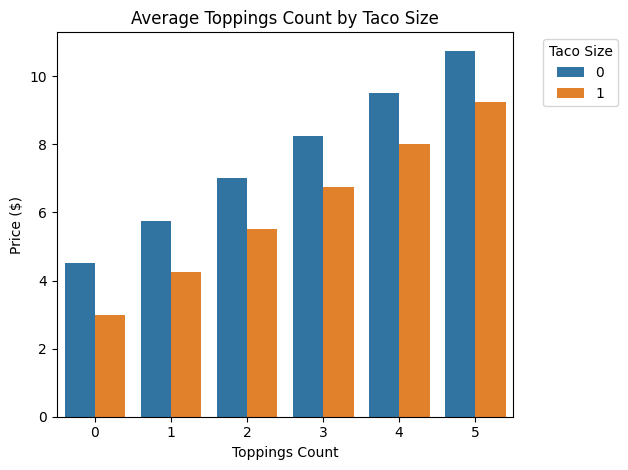

In [55]:
#'Toppings Count','Price ($)' , 'Taco Size'
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize=(12, 20))

sns.barplot(
    data=df,
    x="Toppings Count",
    y="Price ($)",
    hue="Taco Size",
    estimator="mean",
    errorbar=None
)

plt.title("Average Toppings Count by Taco Size")
plt.ylabel("Price ($)")
plt.xlabel("Toppings Count")
plt.legend(title="Taco Size", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [56]:
"""
Designed for:
    Exploratory Data Analysis (EDA)
    Machine Learning model training
    Time series analysis
    Price prediction & delivery optimization studies
"""

'\nDesigned for:\n    Exploratory Data Analysis (EDA)\n    Machine Learning model training\n    Time series analysis\n    Price prediction & delivery optimization studies\n'

In [57]:
from IPython.display import FileLink

df.to_csv("df_taco_sales.csv", index=False)
FileLink("df_taco_sales.csv")

/kaggle/working/df_taco_sales.csv